<a href="https://colab.research.google.com/github/Hemn-Khdr/Multi-Model-AI/blob/main/Phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# SECTION 0 — SETUP
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

# CHANGE THIS TO YOUR OWN DRIVE PATH
file_path = "/content/drive/MyDrive/IEEE and comprehensive/HEMN.csv"

df = pd.read_csv(file_path, low_memory=False)
print("Raw row-level shape:", df.shape)
display(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Raw row-level shape: (808921, 175)


,Age_at_Exam,Sex,sBP,sBP_Date,BMI,BMI_Date,LDL,LDL_Date,HDL,HDL_Date,...,duration_b_R1_[corticosteroid]_Days,total_b_R1_[corticosteroid]_Records,first_b_R1_[1stlineantidiabetic],first_StartDate_b_R1_[1stlineantidiabetic],first_StopDate_b_R1_[1stlineantidiabetic],last_b_R1_[1stlineantidiabetic],last_StartDate_b_R1_[1stlineantidiabetic],last_StopDate_b_R1_[1stlineantidiabetic],duration_b_R1_[1stlineantidiabetic]_Days,total_b_R1_[1stlineantidiabetic]_Records
0,69,Male,140.0,2010-03-18,26.000000,2010-12-17,3.35,2010-03-06,1.03,2010-03-06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,56,Female,120.0,2011-11-03,24.000000,2011-11-03,4.01,2011-10-04,1.84,2011-10-04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,35,Female,100.0,2014-02-21,51.195667,2014-02-21,3.11,2014-02-24,1.26,2014-02-24,...,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,43,Female,138.0,2013-07-04,67.794421,2013-07-04,2.96,2013-08-02,1.09,2013-08-02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,49,Male,141.0,2013-03-13,34.000000,2013-01-24,4.06,2013-01-24,1.34,2013-01-24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# ============================================================
# Modeling / evaluation imports
# ============================================================
from scipy import sparse

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)
from sklearn.calibration import calibration_curve

!pip -q install xgboost transformers torch shap
from xgboost import XGBClassifier

In [ ]:
# ============================================================
# CONFIG
# ============================================================
ID_COL = "Patient_ID"
DIAB_COL = "Diabetes"
DM_COL = "DM_OnsetDate"
STROKE_DATE_COL = "[Stroke_Date]"
DEATH_DATE_COL = "[Deceased_Date]"
TEXT_COL = "concat(DiagnosisText_Orig)"

FEATURE_WINDOW_MONTHS = 6
OUTCOME_HORIZON_YEARS = 5
RANDOM_STATE = 42

# Candidate Phase 1 features from your original work
CANDIDATE_FEATURES = [
    "Age_at_Exam", "Sex",
    "HTN_FW", "AFib_FW", "CAD_FW",
    "sBP_Mean_FW",
    "A1c_Mean_FW", "LDL_Mean_FW", "TG_Mean_FW", "FBS_Mean_FW",
    "BMI_Last_FW",
    "CKD_FW",
]

# Map each engineered feature to the raw date column needed to build it
FEATURE_DATE_MAP = {
    "sBP_Mean_FW": "sBP_Date",
    "BMI_Last_FW": "BMI_Date",
    "LDL_Mean_FW": "LDL_Date",
    "A1c_Mean_FW": "A1c_Date",
    "TG_Mean_FW": "TG_Date",
    "FBS_Mean_FW": "FBS_Date",
    "HTN_FW": "HTN_OnsetDate",
    "AFib_FW": "[AtrialFibrillation_Date]",
    "CAD_FW": "[CAD_Date]",
    "CKD_FW": "[CKD_Date]",
}

print("Config ready.")

Config ready.


Section 1 — Build the common landmark cohort

In [ ]:
# ============================================================
# SECTION 1 — COMMON LANDMARK COHORT
# ============================================================
df1 = df.copy()

# Keep diabetes patients only
if DIAB_COL in df1.columns:
    df1 = df1[df1[DIAB_COL] == 1].copy()

# Keep valid ID and DM onset
df1 = df1[df1[ID_COL].notna() & df1[DM_COL].notna()].copy()

print("After diabetes + ID/onset filters:", df1.shape)
print("Unique patients after diabetes filter:", df1[ID_COL].nunique())

After diabetes + ID/onset filters: (234464, 175)
Unique patients after diabetes filter: 25920


In [ ]:
# Parse essential timeline dates
base_date_cols = [DM_COL, STROKE_DATE_COL, DEATH_DATE_COL]
for c in base_date_cols:
    if c in df1.columns:
        df1[c] = pd.to_datetime(df1[c], errors="coerce")

# Build patient-level timeline
agg_dict = {DM_COL: "min"}
if STROKE_DATE_COL in df1.columns:
    agg_dict[STROKE_DATE_COL] = "min"
if DEATH_DATE_COL in df1.columns:
    agg_dict[DEATH_DATE_COL] = "min"

patient = (
    df1.groupby(ID_COL, as_index=False)
       .agg(agg_dict)
       .rename(columns={
           DM_COL: "DM_OnsetDate",
           STROKE_DATE_COL: "Stroke_Date",
           DEATH_DATE_COL: "Deceased_Date",
       })
)

if "Stroke_Date" not in patient.columns:
    patient["Stroke_Date"] = pd.NaT
if "Deceased_Date" not in patient.columns:
    patient["Deceased_Date"] = pd.NaT

patient["Landmark_Date"] = patient["DM_OnsetDate"] + pd.DateOffset(months=FEATURE_WINDOW_MONTHS)
patient["Horizon_End"]   = patient["DM_OnsetDate"] + pd.DateOffset(years=OUTCOME_HORIZON_YEARS)

print("Patient-level table before exclusions:", patient.shape)
display(patient.head())

Patient-level table before exclusions: (25920, 6)


,Patient_ID,DM_OnsetDate,Stroke_Date,Deceased_Date,Landmark_Date,Horizon_End
0,1001000000001150,2008-10-10,NaT,NaT,2009-04-10,2013-10-10
1,1001000000001343,2011-01-10,NaT,NaT,2011-07-10,2016-01-10
2,1001000000001950,2005-03-15,NaT,NaT,2005-09-15,2010-03-15
3,1001000000002046,2009-10-02,NaT,NaT,2010-04-02,2014-10-02
4,1001000000002528,2014-02-03,NaT,NaT,2014-08-03,2019-02-03


In [ ]:
# Exclusions at prediction time
exclude_early_stroke = patient["Stroke_Date"].notna() & (patient["Stroke_Date"] <= patient["Landmark_Date"])
exclude_early_death  = patient["Deceased_Date"].notna() & (patient["Deceased_Date"] <= patient["Landmark_Date"])

N0 = patient.shape[0]
N1 = int(exclude_early_stroke.sum())
N2 = int(exclude_early_death.sum())

patient = patient[~exclude_early_stroke & ~exclude_early_death].copy()

# Label: stroke AFTER landmark and within 5 years of diabetes onset
patient["y"] = (
    patient["Stroke_Date"].notna()
    & (patient["Stroke_Date"] > patient["Landmark_Date"])
    & (patient["Stroke_Date"] <= patient["Horizon_End"])
).astype(int)

print("N0 (initial diabetes patients):", N0)
print("N1 (excluded: stroke on/before landmark):", N1)
print("N2 (excluded: death on/before landmark):", N2)
print("Final analytic cohort:", patient.shape[0])
print(patient["y"].value_counts(dropna=False))
print("Outcome prevalence:", patient["y"].mean())

N0 (initial diabetes patients): 25920
N1 (excluded: stroke on/before landmark): 51
N2 (excluded: death on/before landmark): 0
Final analytic cohort: 25869
y
0    25788
1       81
Name: count, dtype: int64
Outcome prevalence: 0.0031311608488924967


In [ ]:
# Cohort flow table
cohort_flow = pd.DataFrame({
    "step": [
        "Initial diabetes cohort",
        "Excluded: stroke on/before landmark",
        "Excluded: death on/before landmark",
        "Final analytic cohort"
    ],
    "n": [N0, N1, N2, patient.shape[0]]
})
display(cohort_flow)

,step,n
0,Initial diabetes cohort,25920
1,Excluded: stroke on/before landmark,51
2,Excluded: death on/before landmark,0
3,Final analytic cohort,25869


Section 2 — Build Phase 1-style tabular features

In [ ]:
# ============================================================
# SECTION 2 — BUILD TABULAR FEATURES
# ============================================================
# Only parse raw date columns that actually exist
raw_feature_date_cols = [c for c in FEATURE_DATE_MAP.values() if c in df1.columns]
for c in raw_feature_date_cols:
    df1[c] = pd.to_datetime(df1[c], errors="coerce")

# Attach landmark and label back to row-level data
df2 = df1.merge(
    patient[[ID_COL, "Landmark_Date", "y"]],
    on=ID_COL,
    how="inner"
)

print("Row-level data after merging patient cohort:", df2.shape)
print([c for c in df2.columns if "DM_OnsetDate" in c or c == "Landmark_Date" or c == "y"])

Row-level data after merging patient cohort: (233913, 177)
['DM_OnsetDate', 'Landmark_Date', 'y']


In [ ]:
print(df2.columns.tolist())

['Age_at_Exam', 'Sex', 'sBP', 'sBP_Date', 'BMI', 'BMI_Date', 'LDL', 'LDL_Date', 'HDL', 'HDL_Date', 'A1c', 'A1c_Date', 'TG', 'TG_Date', 'FBS', 'FBS_Date', 'Total_Cholesterol', 'Total_Cholesterol_Lab_Date', 'Diabetes', 'Depression', 'Depression_OnsetDate', 'HTN', 'HTN_OnsetDate', 'OA', 'OA_OnsetDate', 'COPD', 'COPD_Date', 'Patient_ID', 'DM_OnsetDate', 'DM_Onset_Revised_1YrPrior', '[Amputation)', '[Amputation_Date]', '[Anxiety)', '[Anxiety_Date]', '[Arrhythmia)', '[Arrhythmia_Date]', '[AtrialFibrillation)', '[AtrialFibrillation_Date]', '[Blindness)', '[Blindness_Date]', '[CABG)', '[CABG_Date]', '[CAD)', '[CAD_Date]', '[Cancer)', '[Cancer_Date]', '[Cardiomyopathy)', '[Cardiomyopathy_Date]', '[Cataract)', '[Cataract_Date]', '[CKD)', '[CKD_Date]', '[Deceased)', '[Deceased_Date]', '[Depression)', '[Depression_Date]', '[DiabeticFootUlcer)', '[DiabeticFootUlcer_Date]', '[Dialysis)', '[Dialysis_Date]', '[Enteropathy)', '[Enteropathy_Date]', '[ESRD)', '[ESRD_Date]', '[Gangrene)', '[Gangrene_Date]

In [ ]:
def in_fw(date_series, start_series, end_series):
    return date_series.notna() & (date_series >= start_series) & (date_series <= end_series)

# Start patient-level feature table
features_df = patient[[ID_COL, "DM_OnsetDate", "Landmark_Date", "Horizon_End", "y"]].copy()

# Demographics
demo_cols = [c for c in ["Age_at_Exam", "Sex"] if c in df2.columns]
if demo_cols:
    demo = (
        df2.sort_values([ID_COL, DM_COL])
           .groupby(ID_COL, as_index=False)[demo_cols]
           .first()
    )
    features_df = features_df.merge(demo, on=ID_COL, how="left")

In [ ]:
def make_mean_feature(df_, value_col, date_col, new_name):
    if value_col not in df_.columns or date_col not in df_.columns:
        return None
    tmp = df_.loc[in_fw(df_[date_col], df_["DM_OnsetDate"], df_["Landmark_Date"]), [ID_COL, value_col]].copy()
    tmp[value_col] = pd.to_numeric(tmp[value_col], errors="coerce")
    out = tmp.groupby(ID_COL, as_index=False)[value_col].mean()
    out = out.rename(columns={value_col: new_name})
    return out

def make_last_feature(df_, value_col, date_col, new_name):
    if value_col not in df_.columns or date_col not in df_.columns:
        return None
    tmp = df_.loc[in_fw(df_[date_col], df_["DM_OnsetDate"], df_["Landmark_Date"]), [ID_COL, date_col, value_col]].copy()
    tmp[value_col] = pd.to_numeric(tmp[value_col], errors="coerce")
    tmp = tmp.sort_values([ID_COL, date_col]).groupby(ID_COL, as_index=False).tail(1)
    return tmp[[ID_COL, value_col]].rename(columns={value_col: new_name})

def make_flag_feature(df_, date_col, new_name):
    if date_col not in df_.columns:
        return None
    tmp = df_[[ID_COL, "DM_OnsetDate", "Landmark_Date", date_col]].copy()
    tmp[new_name] = (
        tmp[date_col].notna()
        & (tmp[date_col] >= tmp["DM_OnsetDate"])
        & (tmp[date_col] <= tmp["Landmark_Date"])
    ).astype(int)
    out = tmp.groupby(ID_COL, as_index=False)[new_name].max()
    return out

In [ ]:
feature_blocks = []

# Numeric summaries
for value_col, date_col, new_name in [
    ("sBP", "sBP_Date", "sBP_Mean_FW"),
    ("A1c", "A1c_Date", "A1c_Mean_FW"),
    ("LDL", "LDL_Date", "LDL_Mean_FW"),
    ("TG",  "TG_Date",  "TG_Mean_FW"),
    ("FBS", "FBS_Date", "FBS_Mean_FW"),
]:
    out = make_mean_feature(df2, value_col, date_col, new_name)
    if out is not None:
        feature_blocks.append(out)

out = make_last_feature(df2, "BMI", "BMI_Date", "BMI_Last_FW")
if out is not None:
    feature_blocks.append(out)

# Binary flags
for date_col, new_name in [
    ("HTN_OnsetDate", "HTN_FW"),
    ("[AtrialFibrillation_Date]", "AFib_FW"),
    ("[CAD_Date]", "CAD_FW"),
    ("[CKD_Date]", "CKD_FW"),
]:
    out = make_flag_feature(df2, date_col, new_name)
    if out is not None:
        feature_blocks.append(out)

for block in feature_blocks:
    features_df = features_df.merge(block, on=ID_COL, how="left")

print("Built patient-level feature table:", features_df.shape)
display(features_df.head())

Built patient-level feature table: (25869, 17)


,Patient_ID,DM_OnsetDate,Landmark_Date,Horizon_End,y,Age_at_Exam,Sex,sBP_Mean_FW,A1c_Mean_FW,LDL_Mean_FW,TG_Mean_FW,FBS_Mean_FW,BMI_Last_FW,HTN_FW,AFib_FW,CAD_FW,CKD_FW
0,1001000000001150,2008-10-10,2009-04-10,2013-10-10,0,58,Male,131.6,6.775,2.53,1.16,7.625,29.6,0,0,0,0
1,1001000000001343,2011-01-10,2011-07-10,2016-01-10,0,66,Female,130.0,NaN,NaN,NaN,6.650,NaN,0,0,0,0
2,1001000000001950,2005-03-15,2005-09-15,2010-03-15,0,72,Female,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0
3,1001000000002046,2009-10-02,2010-04-02,2014-10-02,0,62,Female,NaN,NaN,2.94,1.69,4.800,NaN,0,0,0,0
4,1001000000002528,2014-02-03,2014-08-03,2019-02-03,0,49,Male,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0


Section 3 — Attach text and restrict to the text-available subgroup

In [ ]:
# ============================================================
# SECTION 3 — ATTACH TEXT
# ============================================================
if TEXT_COL not in df1.columns:
    raise ValueError(f"{TEXT_COL} not found in dataframe.")

text_per_patient = (
    df1.loc[df1[TEXT_COL].notna(), [ID_COL, TEXT_COL]]
       .drop_duplicates(subset=[ID_COL])
       .copy()
)

analysis_df = features_df.merge(text_per_patient, on=ID_COL, how="left")
analysis_df[TEXT_COL] = analysis_df[TEXT_COL].fillna("").astype(str)
analysis_df["has_text"] = (analysis_df[TEXT_COL].str.strip() != "").astype(int)

print("All analytic patients:", analysis_df.shape[0])
print("Patients with text:", int(analysis_df["has_text"].sum()))
print("Patients without text:", int((analysis_df["has_text"] == 0).sum()))
print("Stroke positives overall:", int(analysis_df["y"].sum()))
print("Stroke positives among text-available:", int(analysis_df.loc[analysis_df["has_text"] == 1, "y"].sum()))

All analytic patients: 25869
Patients with text: 4685
Patients without text: 21184
Stroke positives overall: 81
Stroke positives among text-available: 81


In [ ]:
# Restrict to text-available subgroup
analysis_df = analysis_df[analysis_df["has_text"] == 1].copy()

print("Text-available subgroup:", analysis_df.shape)
print(analysis_df["y"].value_counts(dropna=False))
print("Stroke prevalence in text subgroup:", analysis_df["y"].mean())

Text-available subgroup: (4685, 19)
y
0    4604
1      81
Name: count, dtype: int64
Stroke prevalence in text subgroup: 0.01728922091782284


Section 4 — Remove useless variables and related date columns

In [ ]:
# ============================================================
# SECTION 4 — REMOVE VARIABLES WITH NO USABLE VALUES
# ============================================================
existing_candidates = [c for c in CANDIDATE_FEATURES if c in analysis_df.columns]

summary_rows = []
for col in existing_candidates:
    s = analysis_df[col]
    summary_rows.append({
        "variable": col,
        "non_missing_n": int(s.notna().sum()),
        "missing_n": int(s.isna().sum()),
        "missing_pct": round(100 * s.isna().mean(), 2),
        "unique_non_missing": int(s.dropna().nunique()) if s.notna().sum() > 0 else 0
    })

feature_quality = pd.DataFrame(summary_rows).sort_values(
    by=["missing_pct", "unique_non_missing"],
    ascending=[False, True]
)

display(feature_quality)

,variable,non_missing_n,missing_n,missing_pct,unique_non_missing
10,BMI_Last_FW,1900,2785,59.45,1144
6,A1c_Mean_FW,2168,2517,53.72,415
7,LDL_Mean_FW,2279,2406,51.36,840
8,TG_Mean_FW,2309,2376,50.72,808
5,sBP_Mean_FW,2427,2258,48.20,397
9,FBS_Mean_FW,2502,2183,46.60,497
1,Sex,4685,0,0.00,2
2,HTN_FW,4685,0,0.00,2
3,AFib_FW,4685,0,0.00,2
4,CAD_FW,4685,0,0.00,2


In [ ]:
drop_all_missing = []
drop_no_variation = []

for col in existing_candidates:
    s = analysis_df[col]
    if s.notna().sum() == 0:
        drop_all_missing.append(col)
    elif s.dropna().nunique() <= 1:
        drop_no_variation.append(col)

drop_features = sorted(set(drop_all_missing + drop_no_variation))
keep_features = [c for c in existing_candidates if c not in drop_features]

print("Drop all-missing features:", drop_all_missing)
print("Drop single-value / no-variance features:", drop_no_variation)
print("Keep features:", keep_features)

Drop all-missing features: []
Drop single-value / no-variance features: []
Keep features: ['Age_at_Exam', 'Sex', 'HTN_FW', 'AFib_FW', 'CAD_FW', 'sBP_Mean_FW', 'A1c_Mean_FW', 'LDL_Mean_FW', 'TG_Mean_FW', 'FBS_Mean_FW', 'BMI_Last_FW', 'CKD_FW']


In [ ]:
# Remove related raw date columns for dropped engineered features
drop_related_dates = [FEATURE_DATE_MAP[f] for f in drop_features if f in FEATURE_DATE_MAP]
drop_related_dates = [c for c in drop_related_dates if c in df2.columns]

print("Related raw date columns to ignore:", drop_related_dates)

Related raw date columns to ignore: []


In [ ]:
# Final cleaned modeling dataframe
FINAL_TABULAR_FEATURES = keep_features.copy()

model_df = analysis_df[[ID_COL, "y", TEXT_COL] + FINAL_TABULAR_FEATURES].copy()

print("Final modeling dataframe shape:", model_df.shape)
print("Final tabular features:", FINAL_TABULAR_FEATURES)
display(model_df.head())

Final modeling dataframe shape: (4685, 15)
Final tabular features: ['Age_at_Exam', 'Sex', 'HTN_FW', 'AFib_FW', 'CAD_FW', 'sBP_Mean_FW', 'A1c_Mean_FW', 'LDL_Mean_FW', 'TG_Mean_FW', 'FBS_Mean_FW', 'BMI_Last_FW', 'CKD_FW']


,Patient_ID,y,concat(DiagnosisText_Orig),Age_at_Exam,Sex,HTN_FW,AFib_FW,CAD_FW,sBP_Mean_FW,A1c_Mean_FW,LDL_Mean_FW,TG_Mean_FW,FBS_Mean_FW,BMI_Last_FW,CKD_FW
38,1001000000012561,0,depressive disorder - stable|acquired hypothyr...,73,Female,0,0,0,NaN,NaN,3.89,2.39,6.7,NaN,0
70,1001000000024905,0,essential hypertension*|viral warts*|sensory p...,56,Male,1,0,0,134.000000,NaN,3.61,2.25,7.5,NaN,0
152,1001000000081320,0,Diabetes Mellitus Type II|Hypertension|diarrhe...,48,Male,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
161,1001000000082088,0,tinnitus*|hypothyroidism nos|routine medical e...,54,Female,0,0,0,103.333333,5.9,2.22,0.94,5.7,20.151695,0
170,1001000000082404,0,routine medical exam|abdominal pain*|abnormal ...,62,Female,0,0,0,NaN,NaN,3.43,1.54,5.9,NaN,0


Section 5 — Correlation matrix on retained tabular features

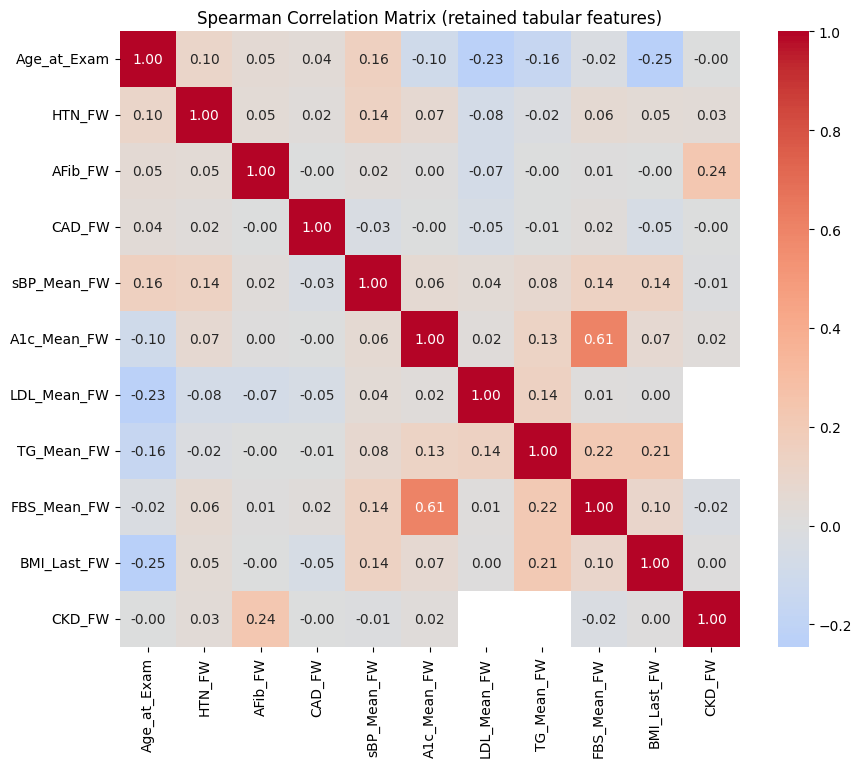

In [ ]:
# ============================================================
# SECTION 5 — CORRELATION MATRIX
# ============================================================
numeric_for_corr = [c for c in FINAL_TABULAR_FEATURES if c != "Sex"]

corr_df = model_df[numeric_for_corr].copy()
for c in corr_df.columns:
    corr_df[c] = pd.to_numeric(corr_df[c], errors="coerce")

if corr_df.shape[1] >= 2:
    corr_matrix = corr_df.corr(method="spearman")
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
    plt.title("Spearman Correlation Matrix (retained tabular features)")
    plt.show()
else:
    print("Not enough numeric features for correlation matrix.")

In [ ]:
# Optional: identify very high correlations
CORR_THRESHOLD = 0.90

if len(numeric_for_corr) >= 2:
    abs_corr = corr_matrix.abs()
    upper = abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))
    high_corr_drop = [col for col in upper.columns if any(upper[col] > CORR_THRESHOLD)]
    print("Highly correlated variables above threshold:", high_corr_drop)
else:
    high_corr_drop = []

Highly correlated variables above threshold: []


Section 6 — Split once at the patient level

In [ ]:
# ============================================================
# SECTION 6 — TRAIN / VALIDATION / TEST SPLIT
# ============================================================
train_ids, temp_ids = train_test_split(
    model_df[ID_COL],
    test_size=0.30,
    stratify=model_df["y"],
    random_state=RANDOM_STATE
)

temp_df = model_df[model_df[ID_COL].isin(temp_ids)].copy()

val_ids, test_ids = train_test_split(
    temp_df[ID_COL],
    test_size=0.50,
    stratify=temp_df["y"],
    random_state=RANDOM_STATE
)

train_df = model_df[model_df[ID_COL].isin(train_ids)].copy()
val_df   = model_df[model_df[ID_COL].isin(val_ids)].copy()
test_df  = model_df[model_df[ID_COL].isin(test_ids)].copy()

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name}: n={len(d)}, positives={int(d['y'].sum())}, prevalence={d['y'].mean():.4f}")

train: n=3279, positives=57, prevalence=0.0174
val: n=703, positives=12, prevalence=0.0171
test: n=703, positives=12, prevalence=0.0171


Section 7 — Shared helpers

In [ ]:
# ============================================================
# SECTION 7 — SHARED HELPERS
# ============================================================
def evaluate_binary(y_true, y_prob, threshold=0.5, model_name="model"):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "model": model_name,
        "threshold": float(threshold),
        "AUROC": float(roc_auc_score(y_true, y_prob)),
        "AUPRC": float(average_precision_score(y_true, y_prob)),
        "Brier": float(brier_score_loss(y_true, y_prob)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
        "F2": float(fbeta_score(y_true, y_pred, beta=2, zero_division=0)),
        "Flagged": int(y_pred.sum())
    }

def find_best_f2_threshold(y_true, y_prob):
    thresholds = np.linspace(0.01, 0.99, 99)
    best_t = 0.5
    best_f2 = -1
    for t in thresholds:
        pred = (y_prob >= t).astype(int)
        score = fbeta_score(y_true, pred, beta=2, zero_division=0)
        if score > best_f2:
            best_f2 = score
            best_t = t
    return best_t, best_f2

def show_confusion(y_true, y_prob, threshold=0.5, title="Confusion Matrix"):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

def plot_calibration(y_true, y_prob, title="Calibration Curve"):
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy="quantile")
    plt.figure(figsize=(5, 4))
    plt.plot(mean_pred, frac_pos, marker="o")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed event rate")
    plt.title(title)
    plt.show()

In [ ]:
# Masking rule for stroke-related terms
MASK_TERMS = [
    "stroke", "cva", "tia", "infarct", "ischemic stroke",
    "cerebrovascular accident", "brain infarct",
    "lacunar infarct", "embolic stroke", "hemorrhagic stroke"
]

mask_pattern = re.compile(
    r"\b(" + "|".join(re.escape(t) for t in sorted(MASK_TERMS, key=len, reverse=True)) + r")\b",
    flags=re.IGNORECASE
)

def mask_stroke_terms(text):
    if pd.isna(text):
        return ""
    return mask_pattern.sub("[MASK_STROKE]", str(text))

for d in [train_df, val_df, test_df]:
    d["text_masked"] = d[TEXT_COL].apply(mask_stroke_terms)

print(train_df["text_masked"].iloc[0][:500])

depressive disorder - stable|acquired hypothyroidism*|diabetes mellitus*|esophageal reflux|gastroduodenal dis nos|sprain of neck|right frozen shoulder|sprain of neck|hyperlipidemia nec/nos|[Phone]|anxiety states*|[Phone]|hypothyroidism nos|depressive disorder nec|dysplasia of cervix - routine f/u|acquired hypothyroidism*|hypothyroidism nos|phobia nos|postmenopausal bleeding|urinary tract dis nos|acquired hypothyroidism*|depressive disorder nec|depressive disorder nec|panic disorder|hypothyroidis


Section 8 — Phase 1 tabular baselines on the text-available subgroup

In [ ]:
# ============================================================
# SECTION 8 — TABULAR-ONLY
# ============================================================
tabular_features = FINAL_TABULAR_FEATURES.copy()

numeric_features = [c for c in tabular_features if c != "Sex"]
categorical_features = [c for c in tabular_features if c == "Sex"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

tab_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

X_train_tab = train_df[tabular_features]
X_val_tab   = val_df[tabular_features]
X_test_tab  = test_df[tabular_features]

y_train = train_df["y"].values
y_val   = val_df["y"].values
y_test  = test_df["y"].values

In [ ]:
# ============================================================
# CHECK MISSING VALUES (TRAIN ONLY)
# ============================================================

missing_summary = X_train_tab.isna().sum().to_frame(name="missing_n")
missing_summary["missing_pct"] = (missing_summary["missing_n"] / len(X_train_tab)) * 100

missing_summary = missing_summary.sort_values("missing_pct", ascending=False)

display(missing_summary)

,missing_n,missing_pct
BMI_Last_FW,1952,59.530345
A1c_Mean_FW,1771,54.010369
LDL_Mean_FW,1691,51.570601
TG_Mean_FW,1670,50.930162
sBP_Mean_FW,1595,48.642879
FBS_Mean_FW,1538,46.904544
Sex,0,0.000000
Age_at_Exam,0,0.000000
AFib_FW,0,0.000000
HTN_FW,0,0.000000


In [ ]:
# ============================================================
# BASIC STATS (TRAIN ONLY)
# ============================================================

display(X_train_tab.describe().T)

,count,mean,std,min,25%,50%,75%,max
Age_at_Exam,3279.0,62.934736,13.248666,18.00,54.000,63.000000,73.00000,90.000000
HTN_FW,3279.0,0.164074,0.370400,0.00,0.000,0.000000,0.00000,1.000000
AFib_FW,3279.0,0.004270,0.065212,0.00,0.000,0.000000,0.00000,1.000000
CAD_FW,3279.0,0.004575,0.067491,0.00,0.000,0.000000,0.00000,1.000000
sBP_Mean_FW,1684.0,130.122142,14.512536,74.00,120.000,130.000000,139.05000,218.000000
A1c_Mean_FW,1508.0,6.835652,1.246471,0.55,6.100,6.500000,7.20000,15.000000
LDL_Mean_FW,1588.0,2.650228,0.961706,0.36,1.920,2.582813,3.27000,7.000000
TG_Mean_FW,1609.0,1.752953,1.080136,0.36,1.090,1.540000,2.16250,16.320000
FBS_Mean_FW,1741.0,7.296061,2.300792,2.90,5.975,6.800000,7.80000,33.800000
BMI_Last_FW,1327.0,31.603195,7.151564,13.50,26.780,30.450000,35.00639,69.493426


 Check exact positive counts in train  then drop

In [ ]:
binary_cols = ["HTN_FW", "AFib_FW", "CAD_FW", "CKD_FW"]

for col in binary_cols:
    n_pos = int(X_train_tab[col].sum())
    n_total = len(X_train_tab)
    print(f"{col}: positives={n_pos}, prevalence={n_pos/n_total:.6f}")

HTN_FW: positives=538, prevalence=0.164074
AFib_FW: positives=14, prevalence=0.004270
CAD_FW: positives=15, prevalence=0.004575
CKD_FW: positives=1, prevalence=0.000305


Drop CKD

In [ ]:
FINAL_TABULAR_FEATURES = [c for c in FINAL_TABULAR_FEATURES if c != "CKD_FW"]
print(FINAL_TABULAR_FEATURES)

['Age_at_Exam', 'Sex', 'HTN_FW', 'AFib_FW', 'CAD_FW', 'sBP_Mean_FW', 'A1c_Mean_FW', 'LDL_Mean_FW', 'TG_Mean_FW', 'FBS_Mean_FW', 'BMI_Last_FW']


In [ ]:
tabular_features = FINAL_TABULAR_FEATURES.copy()

numeric_features = [c for c in tabular_features if c != "Sex"]
categorical_features = [c for c in tabular_features if c == "Sex"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

tab_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

X_train_tab = train_df[tabular_features]
X_val_tab   = val_df[tabular_features]
X_test_tab  = test_df[tabular_features]

In [ ]:
tabular_features = FINAL_TABULAR_FEATURES.copy()

numeric_features = [c for c in tabular_features if c != "Sex"]
categorical_features = [c for c in tabular_features if c == "Sex"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

tab_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

X_train_tab = train_df[tabular_features]
X_val_tab   = val_df[tabular_features]
X_test_tab  = test_df[tabular_features]

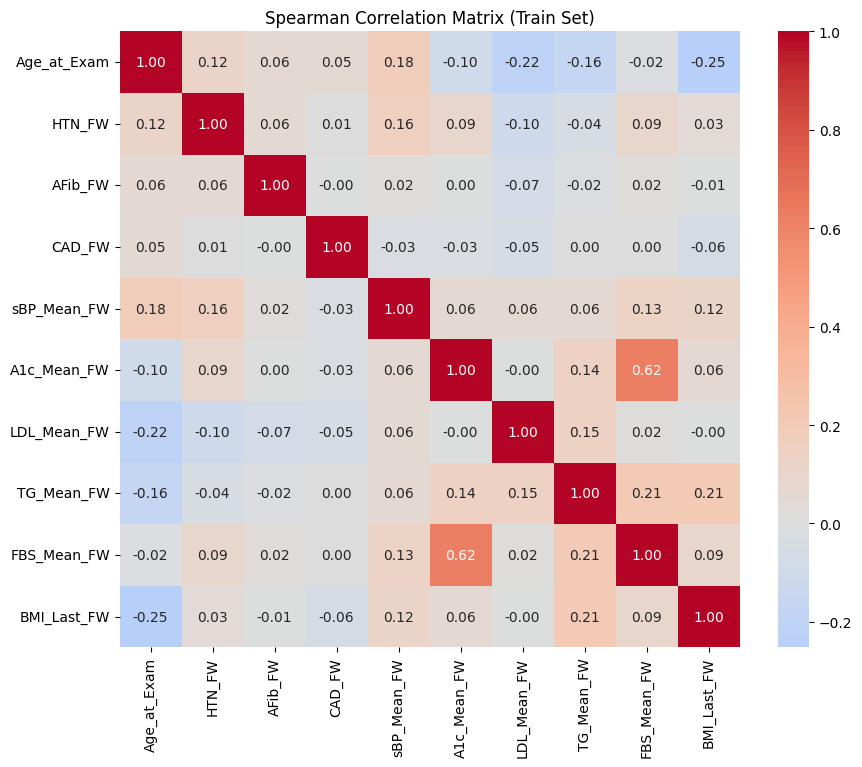

In [ ]:
# ============================================================
# CORRELATION MATRIX (TRAIN ONLY)
# ============================================================

numeric_cols = [c for c in tabular_features if c != "Sex"]

corr_df = X_train_tab[numeric_cols].copy()

for c in corr_df.columns:
    corr_df[c] = pd.to_numeric(corr_df[c], errors="coerce")

corr_matrix = corr_df.corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")

plt.title("Spearman Correlation Matrix (Train Set)")
plt.show()

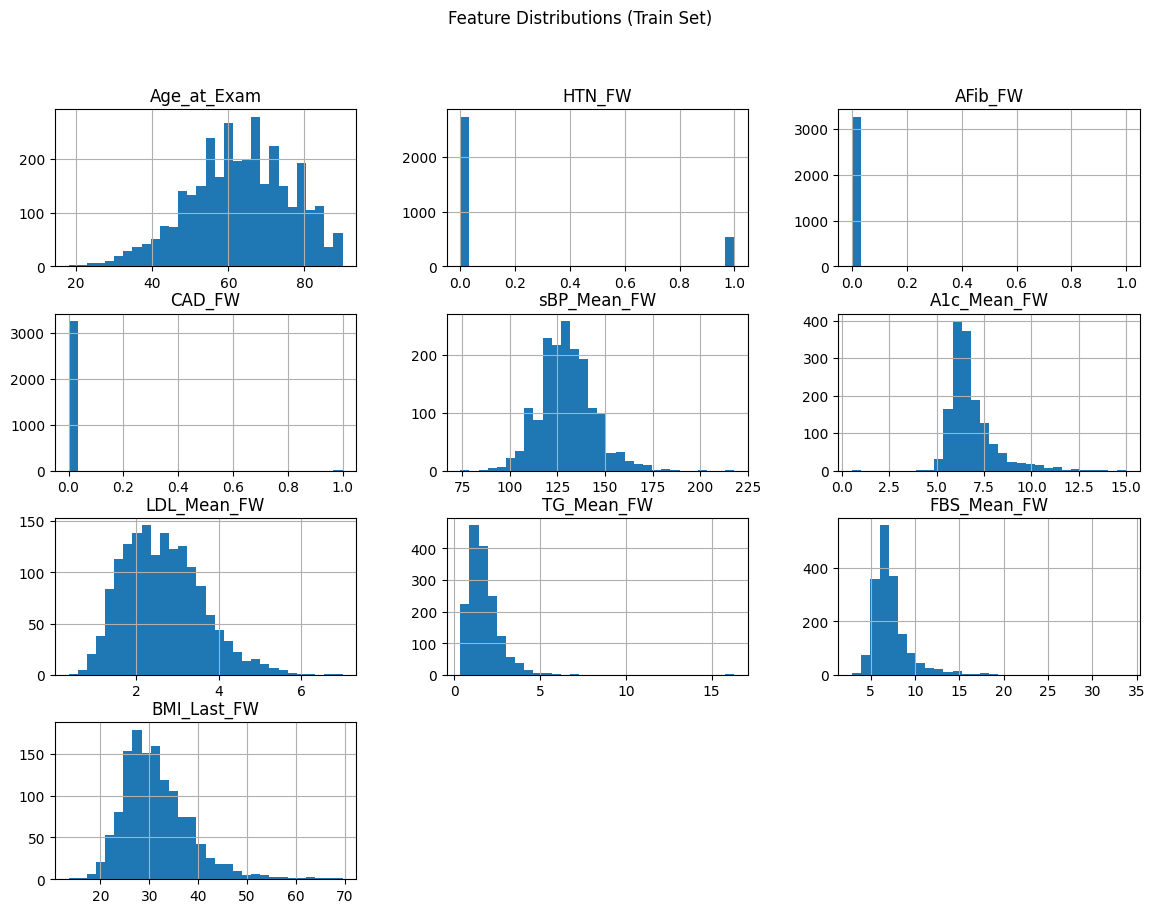

In [ ]:
# ============================================================
# DISTRIBUTIONS (TRAIN ONLY)
# ============================================================

X_train_tab[numeric_cols].hist(
    bins=30,
    figsize=(14, 10)
)

plt.suptitle("Feature Distributions (Train Set)")
plt.show()

In [ ]:
for col in ["AFib_FW", "CAD_FW", "HTN_FW"]:
    print(col)
    print(X_train_tab[col].value_counts())
    print()

AFib_FW
AFib_FW
0    3265
1      14
Name: count, dtype: int64

CAD_FW
CAD_FW
0    3264
1      15
Name: count, dtype: int64

HTN_FW
HTN_FW
0    2741
1     538
Name: count, dtype: int64



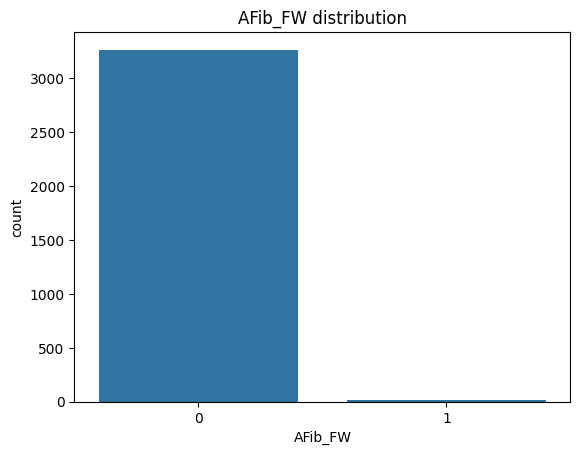

In [ ]:
sns.countplot(x=X_train_tab["AFib_FW"])
plt.title("AFib_FW distribution")
plt.show()

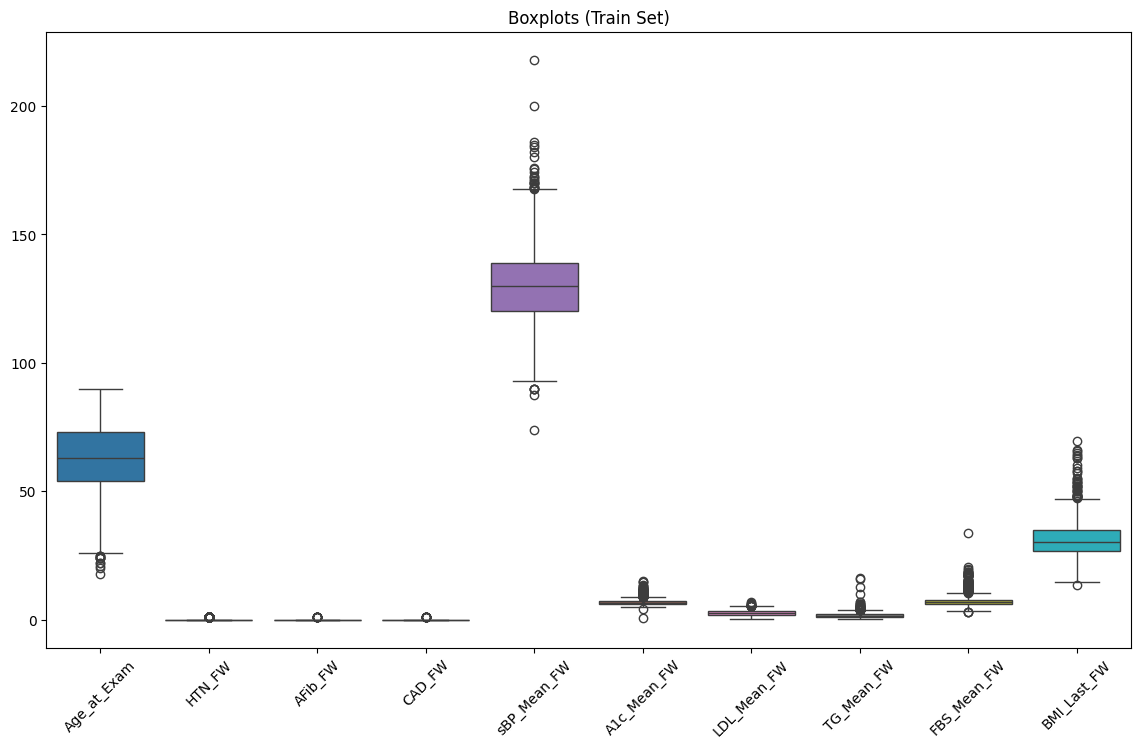

In [ ]:
# ============================================================
# BOXPLOTS (TRAIN ONLY)
# ============================================================

plt.figure(figsize=(14, 8))

sns.boxplot(data=X_train_tab[numeric_cols])
plt.xticks(rotation=45)

plt.title("Boxplots (Train Set)")
plt.show()

In [ ]:
# ============================================================
# OUTLIER SUMMARY (IQR)
# ============================================================

outlier_summary = []

for col in numeric_cols:
    s = X_train_tab[col].dropna()

    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((s < lower) | (s > upper)).sum()

    outlier_summary.append({
        "variable": col,
        "outliers": int(outliers),
        "pct_outliers": round(100 * outliers / len(s), 2)
    })

display(pd.DataFrame(outlier_summary).sort_values("pct_outliers", ascending=False))

,variable,outliers,pct_outliers
1,HTN_FW,538,16.41
8,FBS_Mean_FW,128,7.35
5,A1c_Mean_FW,100,6.63
7,TG_Mean_FW,54,3.36
9,BMI_Last_FW,43,3.24
4,sBP_Mean_FW,31,1.84
6,LDL_Mean_FW,16,1.01
3,CAD_FW,15,0.46
2,AFib_FW,14,0.43
0,Age_at_Exam,12,0.37


In [ ]:
# ============================================================
# OUTLIER SUMMARY (CONTINUOUS FEATURES ONLY)
# ============================================================

continuous_cols = [
    "Age_at_Exam",
    "sBP_Mean_FW",
    "A1c_Mean_FW",
    "LDL_Mean_FW",
    "TG_Mean_FW",
    "FBS_Mean_FW",
    "BMI_Last_FW"
]

continuous_cols = [c for c in continuous_cols if c in X_train_tab.columns]

outlier_summary = []

for col in continuous_cols:
    s = pd.to_numeric(X_train_tab[col], errors="coerce").dropna()

    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((s < lower) | (s > upper)).sum()

    outlier_summary.append({
        "variable": col,
        "outliers": int(outliers),
        "pct_outliers": round(100 * outliers / len(s), 2),
        "lower_bound": round(lower, 3),
        "upper_bound": round(upper, 3)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values("pct_outliers", ascending=False)
display(outlier_df)


,variable,outliers,pct_outliers,lower_bound,upper_bound
5,FBS_Mean_FW,128,7.35,3.237,10.538
2,A1c_Mean_FW,100,6.63,4.450,8.850
4,TG_Mean_FW,54,3.36,-0.519,3.771
6,BMI_Last_FW,43,3.24,14.440,47.346
1,sBP_Mean_FW,31,1.84,91.425,167.625
3,LDL_Mean_FW,16,1.01,-0.105,5.295
0,Age_at_Exam,12,0.37,25.500,101.500


In [ ]:
for col in ["FBS_Mean_FW", "TG_Mean_FW"]:
    X_train_tab[col] = np.log1p(X_train_tab[col])
    X_val_tab[col]   = np.log1p(X_val_tab[col])
    X_test_tab[col]  = np.log1p(X_test_tab[col])

In [ ]:
X_train_tab["A1c_Mean_FW"] = np.log1p(X_train_tab["A1c_Mean_FW"])
X_val_tab["A1c_Mean_FW"]   = np.log1p(X_val_tab["A1c_Mean_FW"])
X_test_tab["A1c_Mean_FW"]  = np.log1p(X_test_tab["A1c_Mean_FW"])

In [ ]:
# ============================================================
# REBUILD TABULAR MODEL PIPELINE
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

tabular_features = FINAL_TABULAR_FEATURES.copy()

numeric_features = [c for c in tabular_features if c != "Sex"]
categorical_features = [c for c in tabular_features if c == "Sex"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

tab_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

tab_lr = Pipeline(steps=[
    ("prep", tab_preprocessor),
    ("clf", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])

In [ ]:
tab_lr.fit(X_train_tab, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age_at_Exam', 'HTN_FW',
                                                   'AFib_FW', 'CAD_FW',
                                                   'sBP_Mean_FW', 'A1c_Mean_FW',
                                                   'LDL_Mean_FW', 'TG_Mean_FW',
                                                   'FBS_Mean_FW',
                                                   'BMI_Last_FW']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=3000,
                                    random_state=42))])

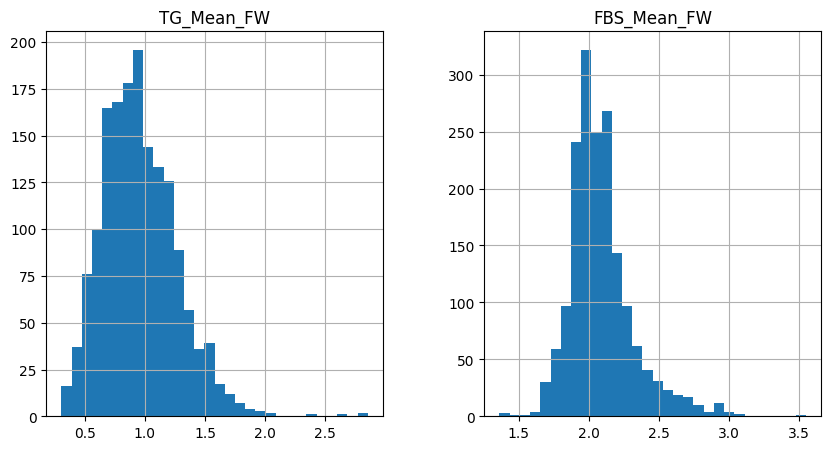

In [ ]:
X_train_tab[["TG_Mean_FW", "FBS_Mean_FW"]].hist(bins=30, figsize=(10,5))
plt.show()

In [ ]:
FINAL_TABULAR_FEATURES = [
    "Age_at_Exam",
    "Sex",
    "HTN_FW",
    "AFib_FW",
    "CAD_FW",
    "sBP_Mean_FW",
    "A1c_Mean_FW",
    "LDL_Mean_FW",
    "TG_Mean_FW",
    "FBS_Mean_FW",
    "BMI_Last_FW"
]

In [ ]:
# Rebuild clean datasets
X_train_tab = train_df[FINAL_TABULAR_FEATURES].copy()
X_val_tab   = val_df[FINAL_TABULAR_FEATURES].copy()
X_test_tab  = test_df[FINAL_TABULAR_FEATURES].copy()

# Apply log transform again (clean + consistent)
for col in ["TG_Mean_FW", "FBS_Mean_FW"]:
    X_train_tab[col] = np.log1p(X_train_tab[col])
    X_val_tab[col]   = np.log1p(X_val_tab[col])
    X_test_tab[col]  = np.log1p(X_test_tab[col])

Plot ALL feature distributions

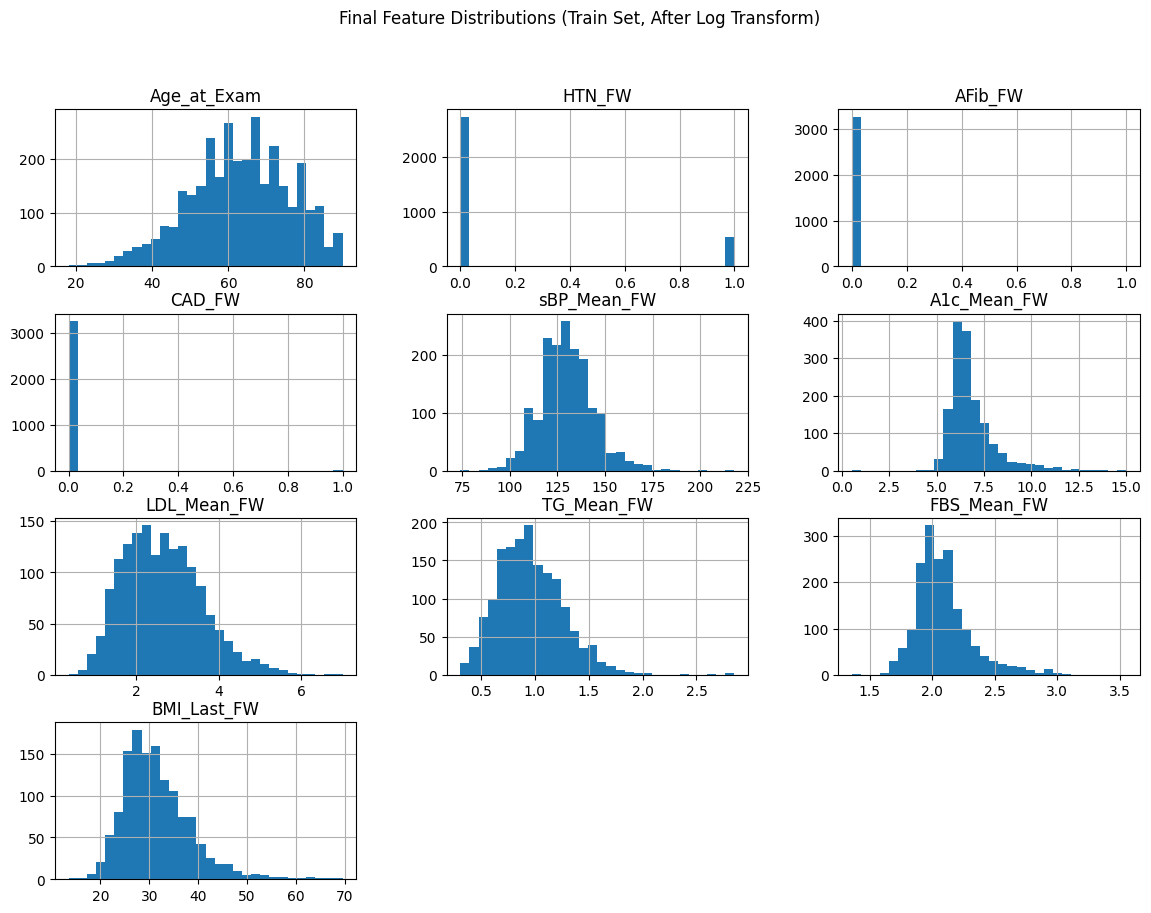

In [ ]:
import matplotlib.pyplot as plt

numeric_cols = [c for c in FINAL_TABULAR_FEATURES if c != "Sex"]

X_train_tab[numeric_cols].hist(
    bins=30,
    figsize=(14, 10)
)

plt.suptitle("Final Feature Distributions (Train Set, After Log Transform)")
plt.show()

Better visualization (recommended)

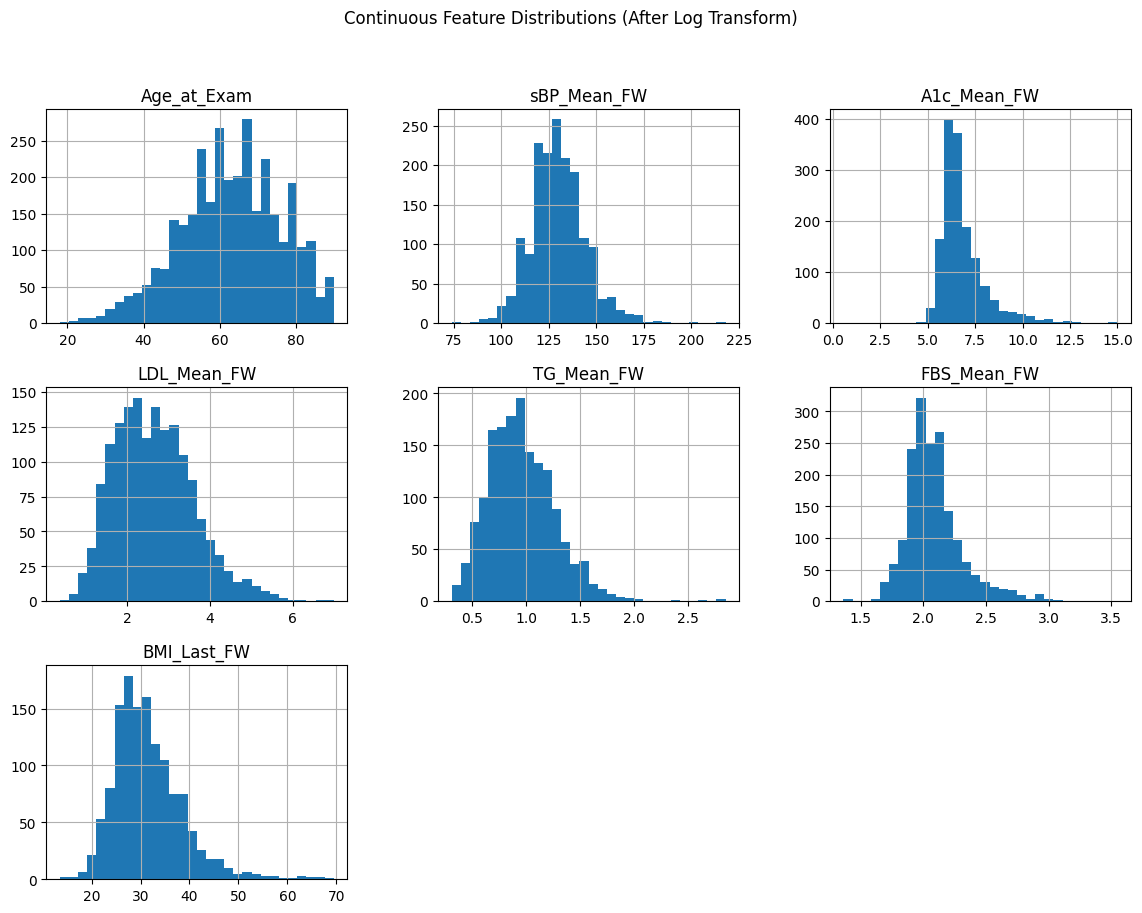

In [ ]:
continuous_cols = [
    "Age_at_Exam",
    "sBP_Mean_FW",
    "A1c_Mean_FW",
    "LDL_Mean_FW",
    "TG_Mean_FW",
    "FBS_Mean_FW",
    "BMI_Last_FW"
]

X_train_tab[continuous_cols].hist(
    bins=30,
    figsize=(14, 10)
)

plt.suptitle("Continuous Feature Distributions (After Log Transform)")
plt.show()

🔹 Binary variables (use countplot)

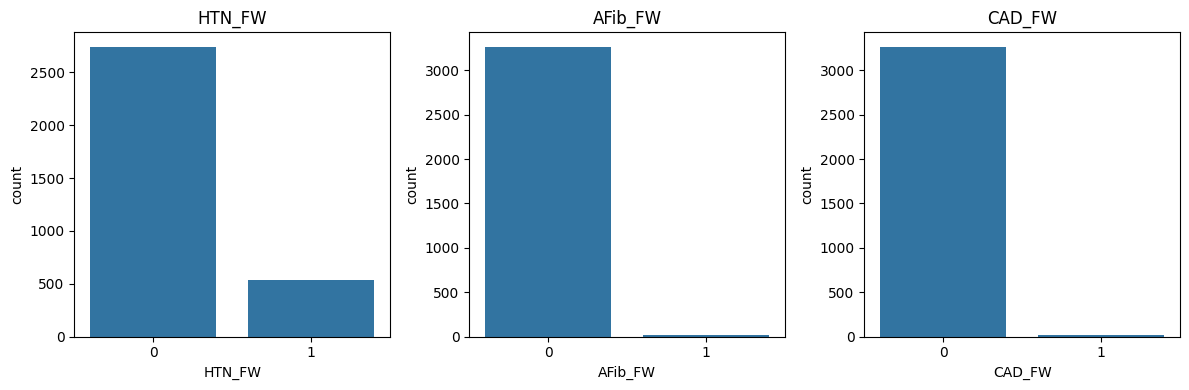

In [ ]:
import seaborn as sns

binary_cols = ["HTN_FW", "AFib_FW", "CAD_FW"]

plt.figure(figsize=(12, 4))

for i, col in enumerate(binary_cols, 1):
    plt.subplot(1, 3, i)
    sns.countplot(x=X_train_tab[col])
    plt.title(col)

plt.tight_layout()
plt.show()

create the tabular feature definition cell

In [ ]:
# ============================================================
# Tabular feature definitions and preprocessing
# ============================================================

NUMERIC_TABULAR_FEATURES = [
    "Age_at_Exam",
    "sBP_Mean_FW",
    "A1c_Mean_FW",
    "LDL_Mean_FW",
    "TG_Mean_FW",
    "FBS_Mean_FW",
    "BMI_Last_FW",
]

CATEGORICAL_TABULAR_FEATURES = [
    "Sex",
    "HTN_FW",
    "AFib_FW",
    "CAD_FW",
]

ALL_TABULAR_FEATURES = NUMERIC_TABULAR_FEATURES + CATEGORICAL_TABULAR_FEATURES

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

tabular_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUMERIC_TABULAR_FEATURES),
        ("cat", categorical_transformer, CATEGORICAL_TABULAR_FEATURES),
    ],
    remainder="drop",
)

print("Numeric features:", NUMERIC_TABULAR_FEATURES)
print("Categorical features:", CATEGORICAL_TABULAR_FEATURES)
print("Total tabular features:", len(ALL_TABULAR_FEATURES))

Numeric features: ['Age_at_Exam', 'sBP_Mean_FW', 'A1c_Mean_FW', 'LDL_Mean_FW', 'TG_Mean_FW', 'FBS_Mean_FW', 'BMI_Last_FW']
Categorical features: ['Sex', 'HTN_FW', 'AFib_FW', 'CAD_FW']
Total tabular features: 11


In [ ]:
NUMERIC_TABULAR_FEATURES = [
    "Age_at_Exam",
    "sBP_Mean_FW",
    "A1c_Mean_FW",
    "LDL_Mean_FW",
    "TG_Mean_FW_log",
    "FBS_Mean_FW_log",
    "BMI_Last_FW",
]

In [ ]:
numeric_transformer
categorical_transformer
tabular_preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age_at_Exam', 'sBP_Mean_FW', 'A1c_Mean_FW',
                                  'LDL_Mean_FW', 'TG_Mean_FW', 'FBS_Mean_FW',
                                  'BMI_Last_FW']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Sex', 'HTN_FW', 'AFib_FW', 'CAD_FW'])])

Phase 1 — Tabular-only models

In [ ]:
# ============================================================
# Imports needed for Phase 1 tabular-only training
# ============================================================

import numpy as np
import pandas as pd

from scipy import sparse

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
)
from xgboost import XGBClassifier

In [ ]:
# ============================================================
# Evaluation utilities for this project
# ============================================================

RANDOM_STATE = 42

def compute_specificity(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else np.nan

def select_best_threshold(y_true, probs, metric="f2"):
    thresholds = np.linspace(0.01, 0.99, 99)
    best_t = 0.50
    best_score = -np.inf

    for t in thresholds:
        pred = (probs >= t).astype(int)

        if metric == "f2":
            score = fbeta_score(y_true, pred, beta=2, zero_division=0)
        elif metric == "f1":
            score = f1_score(y_true, pred, zero_division=0)
        elif metric == "recall":
            score = recall_score(y_true, pred, zero_division=0)
        else:
            raise ValueError("metric must be one of: 'f2', 'f1', 'recall'")

        if score > best_score:
            best_score = score
            best_t = t

    return float(best_t), float(best_score)

def threshold_for_target_recall(y_true, probs, target_recall=0.90):
    thresholds = np.linspace(0.01, 0.99, 99)
    valid = []

    for t in thresholds:
        pred = (probs >= t).astype(int)
        rec = recall_score(y_true, pred, zero_division=0)
        prec = precision_score(y_true, pred, zero_division=0)
        f2 = fbeta_score(y_true, pred, beta=2, zero_division=0)
        flagged = int(pred.sum())

        if rec >= target_recall:
            valid.append((t, rec, prec, f2, flagged))

    if len(valid) == 0:
        # fallback = threshold with highest recall
        best_t, best_recall = select_best_threshold(y_true, probs, metric="recall")
        return float(best_t), {
            "target_met": False,
            "recall": float(best_recall),
        }

    # among thresholds meeting target recall:
    # prefer highest precision, then fewer flagged patients, then higher F2
    valid_sorted = sorted(valid, key=lambda x: (-x[2], x[4], -x[3]))
    t, rec, prec, f2, flagged = valid_sorted[0]

    return float(t), {
        "target_met": True,
        "recall": float(rec),
        "precision": float(prec),
        "f2": float(f2),
        "flagged": int(flagged),
    }

def compute_metrics_from_probs(y_true, probs, threshold=0.50):
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds, labels=[0, 1]).ravel()

    return {
        "roc_auc": float(roc_auc_score(y_true, probs)),
        "pr_auc": float(average_precision_score(y_true, probs)),
        "accuracy": float(accuracy_score(y_true, preds)),
        "precision": float(precision_score(y_true, preds, zero_division=0)),
        "recall": float(recall_score(y_true, preds, zero_division=0)),
        "f1": float(f1_score(y_true, preds, zero_division=0)),
        "f2": float(fbeta_score(y_true, preds, beta=2, zero_division=0)),
        "specificity": float(compute_specificity(y_true, preds)),
        "brier": float(brier_score_loss(y_true, probs)),
        "threshold": float(threshold),
        "TP": int(tp),
        "FP": int(fp),
        "TN": int(tn),
        "FN": int(fn),
        "flagged": int(preds.sum()),
    }

def fit_platt_scaler(val_probs, y_val):
    calibrator = LogisticRegression(random_state=RANDOM_STATE)
    calibrator.fit(np.asarray(val_probs).reshape(-1, 1), np.asarray(y_val))
    return calibrator

def apply_platt_scaler(calibrator, probs):
    return calibrator.predict_proba(np.asarray(probs).reshape(-1, 1))[:, 1]

def plot_roc_pr_curves(y_true, probs, title_prefix="Model"):
    fpr, tpr, _ = roc_curve(y_true, probs)
    precision, recall, _ = precision_recall_curve(y_true, probs)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_true, probs):.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_title(f"{title_prefix} - ROC curve")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.legend()
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(recall, precision, label=f"AP={average_precision_score(y_true, probs):.3f}")
    ax.set_title(f"{title_prefix} - Precision-Recall curve")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend()
    plt.show()

def plot_calibration_curve_custom(y_true, probs, n_bins=10, title="Calibration curve"):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(probs, bins) - 1

    xs, ys = [], []
    for b in range(n_bins):
        mask = bin_ids == b
        if np.sum(mask) == 0:
            continue
        xs.append(np.mean(probs[mask]))
        ys.append(np.mean(np.asarray(y_true)[mask]))

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot([0, 1], [0, 1], linestyle="--", label="Perfect")
    ax.plot(xs, ys, marker="o", label="Model")
    ax.set_title(title)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed fraction positive")
    ax.legend()
    plt.show()

In [ ]:
# ============================================================
# Tabular feature definitions and preprocessing
# ============================================================

NUMERIC_TABULAR_FEATURES = [
    "Age_at_Exam",
    "sBP_Mean_FW",
    "A1c_Mean_FW",
    "LDL_Mean_FW",
    "TG_Mean_FW",
    "FBS_Mean_FW",
    "BMI_Last_FW",
]

CATEGORICAL_TABULAR_FEATURES = [
    "Sex",
    "HTN_FW",
    "AFib_FW",
    "CAD_FW",
]

ALL_TABULAR_FEATURES = NUMERIC_TABULAR_FEATURES + CATEGORICAL_TABULAR_FEATURES

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

tabular_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUMERIC_TABULAR_FEATURES),
        ("cat", categorical_transformer, CATEGORICAL_TABULAR_FEATURES),
    ],
    remainder="drop",
)

print("Numeric features:", NUMERIC_TABULAR_FEATURES)
print("Categorical features:", CATEGORICAL_TABULAR_FEATURES)
print("Total tabular features:", len(ALL_TABULAR_FEATURES))

Numeric features: ['Age_at_Exam', 'sBP_Mean_FW', 'A1c_Mean_FW', 'LDL_Mean_FW', 'TG_Mean_FW', 'FBS_Mean_FW', 'BMI_Last_FW']
Categorical features: ['Sex', 'HTN_FW', 'AFib_FW', 'CAD_FW']
Total tabular features: 11


In [ ]:
# ============================================================
# Cell 13: Phase 1 — Tabular-only training
# Adapted for diabetes cohort -> stroke prediction
# ============================================================

tabular_results = []
tabular_models = {}
tabular_val_probs = {}
tabular_test_probs = {}

# Make sure train_df / val_df / test_df already exist
X_train_tab = train_df[ALL_TABULAR_FEATURES].copy()
X_val_tab = val_df[ALL_TABULAR_FEATURES].copy()
X_test_tab = test_df[ALL_TABULAR_FEATURES].copy()

y_train = train_df["y"].astype(int).values
y_val = val_df["y"].astype(int).values
y_test = test_df["y"].astype(int).values

# ------------------------------------------------------------
# Logistic Regression (tabular)
# ------------------------------------------------------------
tab_lr = Pipeline(steps=[
    ("preprocessor", clone(tabular_preprocessor)),
    ("clf", LogisticRegression(
        max_iter=4000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

tab_lr.fit(X_train_tab, y_train)

val_probs_lr = tab_lr.predict_proba(X_val_tab)[:, 1]
test_probs_lr = tab_lr.predict_proba(X_test_tab)[:, 1]

# Calibration on validation predictions only
cal_lr = fit_platt_scaler(val_probs_lr, y_val)
val_probs_lr_cal = apply_platt_scaler(cal_lr, val_probs_lr)
test_probs_lr_cal = apply_platt_scaler(cal_lr, test_probs_lr)

# Thresholds chosen on validation only
best_t_lr_f2, best_score_lr_f2 = select_best_threshold(y_val, val_probs_lr_cal, metric="f2")
best_t_lr_hr, best_meta_lr_hr = threshold_for_target_recall(y_val, val_probs_lr_cal, target_recall=0.90)

# F2-optimized operating point
metrics_lr_f2 = compute_metrics_from_probs(y_test, test_probs_lr_cal, threshold=best_t_lr_f2)
metrics_lr_f2["model_group"] = "tabular"
metrics_lr_f2["model_name"] = "LogisticRegression"
metrics_lr_f2["operating_point"] = "F2_optimized"
metrics_lr_f2["selection_metric"] = float(best_score_lr_f2)
tabular_results.append(metrics_lr_f2)

# High-recall operating point
metrics_lr_hr = compute_metrics_from_probs(y_test, test_probs_lr_cal, threshold=best_t_lr_hr)
metrics_lr_hr["model_group"] = "tabular"
metrics_lr_hr["model_name"] = "LogisticRegression"
metrics_lr_hr["operating_point"] = "high_recall"
metrics_lr_hr["selection_metric"] = float(best_meta_lr_hr.get("recall", np.nan))
tabular_results.append(metrics_lr_hr)

tabular_models["LogisticRegression"] = tab_lr
tabular_val_probs["LogisticRegression"] = val_probs_lr_cal
tabular_test_probs["LogisticRegression"] = test_probs_lr_cal

# ------------------------------------------------------------
# XGBoost (tabular)
# ------------------------------------------------------------
# Fit a fresh preprocessor outside the LR pipeline so we can feed
# the transformed tabular matrix to XGBoost and later use SHAP.
tabular_preprocessor_xgb = clone(tabular_preprocessor)

X_train_tab_proc = tabular_preprocessor_xgb.fit_transform(X_train_tab)
X_val_tab_proc = tabular_preprocessor_xgb.transform(X_val_tab)
X_test_tab_proc = tabular_preprocessor_xgb.transform(X_test_tab)

if sparse.issparse(X_train_tab_proc):
    X_train_tab_dense = X_train_tab_proc.toarray()
    X_val_tab_dense = X_val_tab_proc.toarray()
    X_test_tab_dense = X_test_tab_proc.toarray()
else:
    X_train_tab_dense = np.asarray(X_train_tab_proc)
    X_val_tab_dense = np.asarray(X_val_tab_proc)
    X_test_tab_dense = np.asarray(X_test_tab_proc)

# Imbalance handling
pos = int(np.sum(y_train == 1))
neg = int(np.sum(y_train == 0))
scale_pos_weight = neg / max(pos, 1)

tab_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=2,
    scale_pos_weight=scale_pos_weight,
)

tab_xgb.fit(X_train_tab_dense, y_train)

val_probs_xgb = tab_xgb.predict_proba(X_val_tab_dense)[:, 1]
test_probs_xgb = tab_xgb.predict_proba(X_test_tab_dense)[:, 1]

# Calibration on validation predictions only
cal_xgb = fit_platt_scaler(val_probs_xgb, y_val)
val_probs_xgb_cal = apply_platt_scaler(cal_xgb, val_probs_xgb)
test_probs_xgb_cal = apply_platt_scaler(cal_xgb, test_probs_xgb)

# Thresholds chosen on validation only
best_t_xgb_f2, best_score_xgb_f2 = select_best_threshold(y_val, val_probs_xgb_cal, metric="f2")
best_t_xgb_hr, best_meta_xgb_hr = threshold_for_target_recall(y_val, val_probs_xgb_cal, target_recall=0.90)

# F2-optimized operating point
metrics_xgb_f2 = compute_metrics_from_probs(y_test, test_probs_xgb_cal, threshold=best_t_xgb_f2)
metrics_xgb_f2["model_group"] = "tabular"
metrics_xgb_f2["model_name"] = "XGBoost"
metrics_xgb_f2["operating_point"] = "F2_optimized"
metrics_xgb_f2["selection_metric"] = float(best_score_xgb_f2)
tabular_results.append(metrics_xgb_f2)

# High-recall operating point
metrics_xgb_hr = compute_metrics_from_probs(y_test, test_probs_xgb_cal, threshold=best_t_xgb_hr)
metrics_xgb_hr["model_group"] = "tabular"
metrics_xgb_hr["model_name"] = "XGBoost"
metrics_xgb_hr["operating_point"] = "high_recall"
metrics_xgb_hr["selection_metric"] = float(best_meta_xgb_hr.get("recall", np.nan))
tabular_results.append(metrics_xgb_hr)

tabular_models["XGBoost"] = tab_xgb
tabular_val_probs["XGBoost"] = val_probs_xgb_cal
tabular_test_probs["XGBoost"] = test_probs_xgb_cal

# Optional: keep transformed matrices for later SHAP / inspection
tabular_models["XGBoost_preprocessor"] = tabular_preprocessor_xgb
tabular_models["XGBoost_feature_names"] = tabular_preprocessor_xgb.get_feature_names_out()
tabular_models["XGBoost_X_train_dense"] = X_train_tab_dense
tabular_models["XGBoost_X_val_dense"] = X_val_tab_dense
tabular_models["XGBoost_X_test_dense"] = X_test_tab_dense

# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------
tabular_results_df = pd.DataFrame(tabular_results).sort_values(
    ["pr_auc", "recall"],
    ascending=[False, False]
).reset_index(drop=True)

display(tabular_results_df)

,roc_auc,pr_auc,accuracy,precision,recall,f1,f2,specificity,brier,threshold,TP,FP,TN,FN,flagged,model_group,model_name,operating_point,selection_metric
0,0.634768,0.043375,0.017070,0.017070,1.000000,0.033566,0.079893,0.000000,0.016736,0.01,12,691,0,0,703,tabular,LogisticRegression,high_recall,1.00000
1,0.634768,0.043375,0.790896,0.034483,0.416667,0.063694,0.129534,0.797395,0.016736,0.02,5,140,551,7,145,tabular,LogisticRegression,F2_optimized,0.15544
2,0.467258,0.017713,0.017070,0.017070,1.000000,0.033566,0.079893,0.000000,0.016809,0.01,12,691,0,0,703,tabular,XGBoost,high_recall,1.00000
3,0.467258,0.017713,0.844950,0.010101,0.083333,0.018018,0.034014,0.858177,0.016809,0.02,1,98,593,11,99,tabular,XGBoost,F2_optimized,0.10274


Best tabular model (by PR AUC among F2-optimized rows): LogisticRegression


,value
roc_auc,0.634768
pr_auc,0.043375
accuracy,0.790896
precision,0.034483
recall,0.416667
f1,0.063694
f2,0.129534
specificity,0.797395
brier,0.016736
threshold,0.02


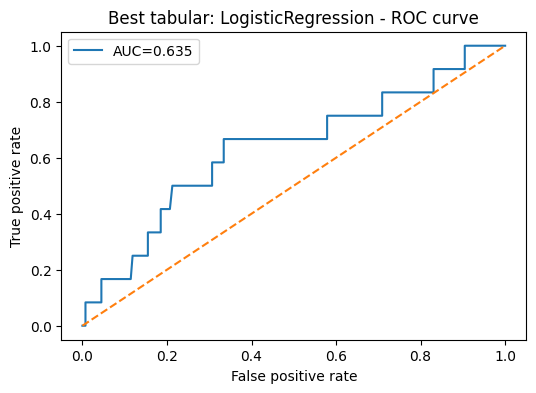

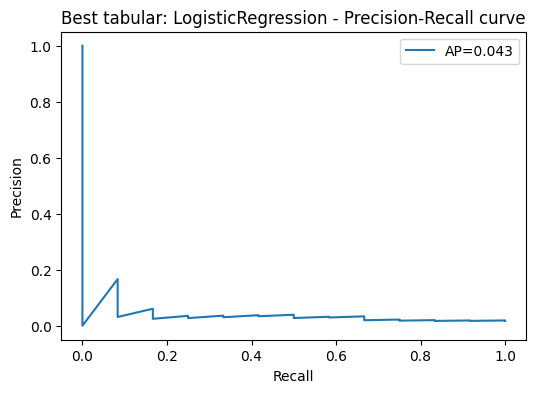

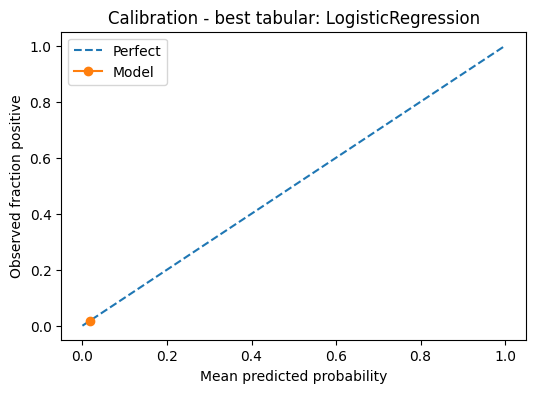

In [ ]:
# ============================================================
# Cell 14: Tabular result plots (adapted for diabetes->stroke)
# ============================================================

# Choose the main tabular result using F2-optimized rows only,
# then rank by PR AUC (main metric under severe imbalance).
best_tab_row = (
    tabular_results_df[tabular_results_df["operating_point"] == "F2_optimized"]
    .sort_values(["pr_auc", "recall"], ascending=[False, False])
    .iloc[0]
)

best_tab_model_name = best_tab_row["model_name"]
best_tab_test_probs = tabular_test_probs[best_tab_model_name]

print("Best tabular model (by PR AUC among F2-optimized rows):", best_tab_model_name)
display(pd.DataFrame(best_tab_row).rename(columns={best_tab_row.name: "value"}))

# Plots use calibrated test probabilities
plot_roc_pr_curves(
    y_test,
    best_tab_test_probs,
    title_prefix=f"Best tabular: {best_tab_model_name}"
)

plot_calibration_curve_custom(
    y_test,
    best_tab_test_probs,
    title=f"Calibration - best tabular: {best_tab_model_name}"
)

In [ ]:
def summarize_result(result_dict):
    return pd.DataFrame([result_dict]).T.rename(columns={0: "value"})

In [ ]:
display(summarize_result(best_tab_row.to_dict()))

,value
roc_auc,0.634768
pr_auc,0.043375
accuracy,0.790896
precision,0.034483
recall,0.416667
f1,0.063694
f2,0.129534
specificity,0.797395
brier,0.016736
threshold,0.02


In [ ]:
# ============================================================
# Optional: compare the two LR operating points
# ============================================================

lr_rows = tabular_results_df[tabular_results_df["model_name"] == "LogisticRegression"].copy()
display(lr_rows[[
    "model_name", "operating_point", "roc_auc", "pr_auc",
    "precision", "recall", "f1", "f2",
    "threshold", "TP", "FP", "TN", "FN", "flagged"
]])

,model_name,operating_point,roc_auc,pr_auc,precision,recall,f1,f2,threshold,TP,FP,TN,FN,flagged
0,LogisticRegression,high_recall,0.634768,0.043375,0.017070,1.000000,0.033566,0.079893,0.01,12,691,0,0,703
1,LogisticRegression,F2_optimized,0.634768,0.043375,0.034483,0.416667,0.063694,0.129534,0.02,5,140,551,7,145


Phase 2 — Text-only models

In [ ]:
import re
import pandas as pd

MASK_TERMS = [
    "ischemic stroke",
    "hemorrhagic stroke",
    "embolic stroke",
    "lacunar infarct",
    "cerebrovascular accident",
    "brain infarct",
    "cerebral infarct",
    "history of stroke",
    "post-stroke",
    "post stroke",
    "cerebrovascular",
    "infarct",
    "stroke",
    "cva",
    "tia",
    "hemiparesis",
    "hemiplegia",
]

def make_delete_pattern(mask_terms):
    ordered = sorted(set(mask_terms), key=len, reverse=True)
    return re.compile(
        r"\b(" + "|".join(re.escape(t) for t in ordered) + r")\b",
        flags=re.IGNORECASE,
    )

DELETE_PATTERN = make_delete_pattern(MASK_TERMS)

def delete_outcome_terms(text):
    text = "" if pd.isna(text) else str(text)
    text = DELETE_PATTERN.sub(" ", text)          # delete, don't replace
    text = re.sub(r"\s+", " ", text).strip()      # normalize whitespace
    return text

In [ ]:
# ============================================================
# Cell 15: Text-only classical models
# FULL REBUILD VERSION
# This cell recreates everything needed for Cell 20
# ============================================================

import re
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# ------------------------------------------------------------
# 1) Define outcome-related terms to delete
# ------------------------------------------------------------
MASK_TERMS = [
    "ischemic stroke",
    "hemorrhagic stroke",
    "embolic stroke",
    "lacunar infarct",
    "cerebrovascular accident",
    "brain infarct",
    "cerebral infarct",
    "history of stroke",
    "post-stroke",
    "post stroke",
    "cerebrovascular",
    "infarct",
    "stroke",
    "cva",
    "tia",
    "hemiparesis",
    "hemiplegia",
]

def make_delete_pattern(mask_terms):
    ordered = sorted(set(mask_terms), key=len, reverse=True)
    return re.compile(
        r"\b(" + "|".join(re.escape(t) for t in ordered) + r")\b",
        flags=re.IGNORECASE,
    )

DELETE_PATTERN = make_delete_pattern(MASK_TERMS)

def delete_outcome_terms(text):
    text = "" if pd.isna(text) else str(text)
    text = DELETE_PATTERN.sub(" ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# ------------------------------------------------------------
# 2) Apply cleaning directly to the working dataframes
# ------------------------------------------------------------
RAW_TEXT_COL = "concat(DiagnosisText_Orig)"
TEXT_INPUT_COL = "text_cleaned"

for d in [train_df, val_df, test_df]:
    d[TEXT_INPUT_COL] = d[RAW_TEXT_COL].fillna("").astype(str).apply(delete_outcome_terms)

# ------------------------------------------------------------
# 3) Confirm cleaning changed rows
# ------------------------------------------------------------
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    n_changed = (d[RAW_TEXT_COL].fillna("").astype(str) != d[TEXT_INPUT_COL]).sum()
    print(f"{name}: {n_changed} rows changed")

# ------------------------------------------------------------
# 4) Build text lists from CLEANED text only
# ------------------------------------------------------------
train_text = train_df[TEXT_INPUT_COL].fillna("").astype(str).tolist()
val_text = val_df[TEXT_INPUT_COL].fillna("").astype(str).tolist()
test_text = test_df[TEXT_INPUT_COL].fillna("").astype(str).tolist()

y_train = train_df["y"].astype(int).values
y_val = val_df["y"].astype(int).values
y_test = test_df["y"].astype(int).values

# ------------------------------------------------------------
# 5) Hard reset all model containers
# ------------------------------------------------------------
text_results = []
text_vectorizers = {}
text_models = {}
text_val_probs = {}
text_test_probs = {}
text_train_mats = {}
text_val_mats = {}
text_test_mats = {}

# ------------------------------------------------------------
# 6) Define classical text models
# ------------------------------------------------------------
TEXT_MODEL_SPECS = {
    "BOW_unigram": CountVectorizer(
        analyzer="word",
        ngram_range=(1, 1),
        min_df=3,
        max_features=50000,
        stop_words="english",
        lowercase=True,
    ),
    "BOW_bigram": CountVectorizer(
        analyzer="word",
        ngram_range=(1, 2),
        min_df=3,
        max_features=80000,
        stop_words="english",
        lowercase=True,
    ),
    "TFIDF_word": TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 2),
        min_df=3,
        max_features=80000,
        stop_words="english",
        sublinear_tf=True,
        lowercase=True,
    ),
    "TFIDF_char": TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=3,
        max_features=100000,
        sublinear_tf=True,
        lowercase=True,
    ),
}

# ------------------------------------------------------------
# 7) Train and store everything needed later
# ------------------------------------------------------------
for model_name, vectorizer in TEXT_MODEL_SPECS.items():
    print(f"Training {model_name}...")

    X_train_txt = vectorizer.fit_transform(train_text)
    X_val_txt = vectorizer.transform(val_text)
    X_test_txt = vectorizer.transform(test_text)

    clf = LogisticRegression(
        max_iter=4000,
        class_weight="balanced",
        solver="saga",
        random_state=RANDOM_STATE,
    )
    clf.fit(X_train_txt, y_train)

    val_probs = clf.predict_proba(X_val_txt)[:, 1]
    test_probs = clf.predict_proba(X_test_txt)[:, 1]

    calibrator = fit_platt_scaler(val_probs, y_val)
    val_probs_cal = apply_platt_scaler(calibrator, val_probs)
    test_probs_cal = apply_platt_scaler(calibrator, test_probs)

    # F2 row
    best_t_f2, best_score_f2 = select_best_threshold(y_val, val_probs_cal, metric="f2")
    metrics_f2 = compute_metrics_from_probs(y_test, test_probs_cal, threshold=best_t_f2)
    metrics_f2["model_group"] = "text"
    metrics_f2["model_name"] = model_name
    metrics_f2["operating_point"] = "F2_optimized"
    metrics_f2["selection_metric"] = float(best_score_f2)
    text_results.append(metrics_f2)

    # High-recall row
    best_t_hr, best_meta_hr = threshold_for_target_recall(
        y_val, val_probs_cal, target_recall=0.90
    )
    metrics_hr = compute_metrics_from_probs(y_test, test_probs_cal, threshold=best_t_hr)
    metrics_hr["model_group"] = "text"
    metrics_hr["model_name"] = model_name
    metrics_hr["operating_point"] = "high_recall"
    metrics_hr["selection_metric"] = float(best_meta_hr.get("recall", np.nan))
    text_results.append(metrics_hr)

    # STORE FOR LATER CELLS
    text_vectorizers[model_name] = vectorizer
    text_models[model_name] = clf
    text_val_probs[model_name] = val_probs_cal
    text_test_probs[model_name] = test_probs_cal
    text_train_mats[model_name] = X_train_txt
    text_val_mats[model_name] = X_val_txt
    text_test_mats[model_name] = X_test_txt

# ------------------------------------------------------------
# 8) Final results table
# ------------------------------------------------------------
text_results_df = pd.DataFrame(text_results).sort_values(
    ["pr_auc", "recall"], ascending=[False, False]
).reset_index(drop=True)

display(text_results_df)

# ------------------------------------------------------------
# 9) IMPORTANT CHECK FOR CELL 20
# ------------------------------------------------------------
print("\nStored keys after rebuild:")
print("text_train_mats:", list(text_train_mats.keys()))
print("text_val_mats:", list(text_val_mats.keys()))
print("text_test_mats:", list(text_test_mats.keys()))
print("text_vectorizers:", list(text_vectorizers.keys()))
print("text_models:", list(text_models.keys()))

train: 889 rows changed
val: 193 rows changed
test: 204 rows changed
Training BOW_unigram...
Training BOW_bigram...
Training TFIDF_word...
Training TFIDF_char...


,roc_auc,pr_auc,accuracy,precision,recall,f1,f2,specificity,brier,threshold,TP,FP,TN,FN,flagged,model_group,model_name,operating_point,selection_metric
0,0.752050,0.241058,0.358464,0.025918,1.000000,0.050526,0.117417,0.347323,0.016484,0.01,12,451,240,0,463,text,TFIDF_char,high_recall,0.916667
1,0.752050,0.241058,0.926031,0.100000,0.416667,0.161290,0.255102,0.934877,0.016484,0.04,5,45,646,7,50,text,TFIDF_char,F2_optimized,0.247525
2,0.678968,0.034457,0.017070,0.017070,1.000000,0.033566,0.079893,0.000000,0.016725,0.01,12,691,0,0,703,text,TFIDF_word,high_recall,1.000000
3,0.678968,0.034457,0.866287,0.023256,0.166667,0.040816,0.074627,0.878437,0.016725,0.03,2,84,607,10,86,text,TFIDF_word,F2_optimized,0.182482
4,0.435721,0.017241,0.017070,0.017070,1.000000,0.033566,0.079893,0.000000,0.016790,0.01,12,691,0,0,703,text,BOW_unigram,F2_optimized,0.079893
5,0.435721,0.017241,0.017070,0.017070,1.000000,0.033566,0.079893,0.000000,0.016790,0.01,12,691,0,0,703,text,BOW_unigram,high_recall,1.000000
6,0.411360,0.015937,0.017070,0.017070,1.000000,0.033566,0.079893,0.000000,0.016779,0.01,12,691,0,0,703,text,BOW_bigram,F2_optimized,0.079893
7,0.411360,0.015937,0.017070,0.017070,1.000000,0.033566,0.079893,0.000000,0.016779,0.01,12,691,0,0,703,text,BOW_bigram,high_recall,1.000000



Stored keys after rebuild:
text_train_mats: ['BOW_unigram', 'BOW_bigram', 'TFIDF_word', 'TFIDF_char']
text_val_mats: ['BOW_unigram', 'BOW_bigram', 'TFIDF_word', 'TFIDF_char']
text_test_mats: ['BOW_unigram', 'BOW_bigram', 'TFIDF_word', 'TFIDF_char']
text_vectorizers: ['BOW_unigram', 'BOW_bigram', 'TFIDF_word', 'TFIDF_char']
text_models: ['BOW_unigram', 'BOW_bigram', 'TFIDF_word', 'TFIDF_char']


In [ ]:
# ============================================================
# Cell 15: Text-only classical models
# Corrected for diabetes cohort -> stroke prediction
# IMPORTANT:
# - deletes outcome-related terms instead of replacing with MASK
# - applies cleaning directly to train_df / val_df / test_df
# - forces models to use text_cleaned
# ============================================================

import re
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1) Define outcome-related terms to delete
# ------------------------------------------------------------
MASK_TERMS = [
    "ischemic stroke",
    "hemorrhagic stroke",
    "embolic stroke",
    "lacunar infarct",
    "cerebrovascular accident",
    "brain infarct",
    "cerebral infarct",
    "history of stroke",
    "post-stroke",
    "post stroke",
    "cerebrovascular",
    "infarct",
    "stroke",
    "cva",
    "tia",
    "hemiparesis",
    "hemiplegia",
]

def make_delete_pattern(mask_terms):
    ordered = sorted(set(mask_terms), key=len, reverse=True)
    return re.compile(
        r"\b(" + "|".join(re.escape(t) for t in ordered) + r")\b",
        flags=re.IGNORECASE,
    )

DELETE_PATTERN = make_delete_pattern(MASK_TERMS)

def delete_outcome_terms(text):
    text = "" if pd.isna(text) else str(text)
    text = DELETE_PATTERN.sub(" ", text)      # delete, do not replace
    text = re.sub(r"\s+", " ", text).strip()  # normalize whitespace
    return text

# ------------------------------------------------------------
# 2) Apply deletion directly to the working dataframes
# ------------------------------------------------------------
RAW_TEXT_COL = "concat(DiagnosisText_Orig)"
TEXT_INPUT_COL = "text_cleaned"

for d in [train_df, val_df, test_df]:
    d[TEXT_INPUT_COL] = d[RAW_TEXT_COL].fillna("").astype(str).apply(delete_outcome_terms)

# ------------------------------------------------------------
# 3) Sanity checks: confirm cleaning actually happened
# ------------------------------------------------------------
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    n_changed = (d[RAW_TEXT_COL].fillna("").astype(str) != d[TEXT_INPUT_COL]).sum()
    print(f"{name}: {n_changed} rows changed")

train_text = train_df[TEXT_INPUT_COL].fillna("").astype(str).tolist()
val_text = val_df[TEXT_INPUT_COL].fillna("").astype(str).tolist()
test_text = test_df[TEXT_INPUT_COL].fillna("").astype(str).tolist()

print("\nSanity checks on cleaned text:")
print("Any [MASK left in train_text? ", any("[MASK" in t for t in train_text))
print("Any 'stroke' left in train_text? ", any("stroke" in t.lower() for t in train_text))
print("Any 'tia' left in train_text? ", any("tia" in t.lower() for t in train_text))
print("Any 'cva' left in train_text? ", any("cva" in t.lower() for t in train_text))

# ------------------------------------------------------------
# 4) Prepare containers
# ------------------------------------------------------------
text_results = []
text_vectorizers = {}
text_models = {}
text_val_probs = {}
text_test_probs = {}
text_train_mats = {}
text_val_mats = {}
text_test_mats = {}

y_train = train_df["y"].astype(int).values
y_val = val_df["y"].astype(int).values
y_test = test_df["y"].astype(int).values

# ------------------------------------------------------------
# 5) Define classical text models
# ------------------------------------------------------------
TEXT_MODEL_SPECS = {
    "BOW_unigram": CountVectorizer(
        analyzer="word",
        ngram_range=(1, 1),
        min_df=3,
        max_features=50000,
        stop_words="english",
        lowercase=True,
    ),
    "BOW_bigram": CountVectorizer(
        analyzer="word",
        ngram_range=(1, 2),
        min_df=3,
        max_features=80000,
        stop_words="english",
        lowercase=True,
    ),
    "TFIDF_word": TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 2),
        min_df=3,
        max_features=80000,
        stop_words="english",
        sublinear_tf=True,
        lowercase=True,
    ),
    "TFIDF_char": TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=3,
        max_features=100000,
        sublinear_tf=True,
        lowercase=True,
    ),
}

# ------------------------------------------------------------
# 6) Train text-only classical models
# ------------------------------------------------------------
for model_name, vectorizer in TEXT_MODEL_SPECS.items():
    X_train_txt = vectorizer.fit_transform(train_text)
    X_val_txt = vectorizer.transform(val_text)
    X_test_txt = vectorizer.transform(test_text)

    clf = LogisticRegression(
        max_iter=4000,
        class_weight="balanced",
        solver="saga",
        random_state=RANDOM_STATE,
    )
    clf.fit(X_train_txt, y_train)

    val_probs = clf.predict_proba(X_val_txt)[:, 1]
    test_probs = clf.predict_proba(X_test_txt)[:, 1]

    calibrator = fit_platt_scaler(val_probs, y_val)
    val_probs_cal = apply_platt_scaler(calibrator, val_probs)
    test_probs_cal = apply_platt_scaler(calibrator, test_probs)

    # F2-optimized operating point
    best_t_f2, best_score_f2 = select_best_threshold(y_val, val_probs_cal, metric="f2")
    metrics_f2 = compute_metrics_from_probs(y_test, test_probs_cal, threshold=best_t_f2)
    metrics_f2["model_group"] = "text"
    metrics_f2["model_name"] = model_name
    metrics_f2["operating_point"] = "F2_optimized"
    metrics_f2["selection_metric"] = float(best_score_f2)
    text_results.append(metrics_f2)

    # High-recall operating point
    best_t_hr, best_meta_hr = threshold_for_target_recall(
        y_val, val_probs_cal, target_recall=0.90
    )
    metrics_hr = compute_metrics_from_probs(y_test, test_probs_cal, threshold=best_t_hr)
    metrics_hr["model_group"] = "text"
    metrics_hr["model_name"] = model_name
    metrics_hr["operating_point"] = "high_recall"
    metrics_hr["selection_metric"] = float(best_meta_hr.get("recall", np.nan))
    text_results.append(metrics_hr)

    text_vectorizers[model_name] = vectorizer
    text_models[model_name] = clf
    text_val_probs[model_name] = val_probs_cal
    text_test_probs[model_name] = test_probs_cal
    text_train_mats[model_name] = X_train_txt
    text_val_mats[model_name] = X_val_txt
    text_test_mats[model_name] = X_test_txt

# ------------------------------------------------------------
# 7) Final results table
# ------------------------------------------------------------
text_results_df = pd.DataFrame(text_results).sort_values(
    ["pr_auc", "recall"], ascending=[False, False]
).reset_index(drop=True)

display(text_results_df)

train: 889 rows changed
val: 193 rows changed
test: 204 rows changed

Sanity checks on cleaned text:
Any [MASK left in train_text?  False
Any 'stroke' left in train_text?  True
Any 'tia' left in train_text?  True
Any 'cva' left in train_text?  True


,roc_auc,pr_auc,accuracy,precision,recall,f1,f2,specificity,brier,threshold,TP,FP,TN,FN,flagged,model_group,model_name,operating_point,selection_metric
0,0.752050,0.241058,0.358464,0.025918,1.000000,0.050526,0.117417,0.347323,0.016484,0.01,12,451,240,0,463,text,TFIDF_char,high_recall,0.916667
1,0.752050,0.241058,0.926031,0.100000,0.416667,0.161290,0.255102,0.934877,0.016484,0.04,5,45,646,7,50,text,TFIDF_char,F2_optimized,0.247525
2,0.678968,0.034457,0.017070,0.017070,1.000000,0.033566,0.079893,0.000000,0.016725,0.01,12,691,0,0,703,text,TFIDF_word,high_recall,1.000000
3,0.678968,0.034457,0.866287,0.023256,0.166667,0.040816,0.074627,0.878437,0.016725,0.03,2,84,607,10,86,text,TFIDF_word,F2_optimized,0.182482
4,0.435721,0.017241,0.017070,0.017070,1.000000,0.033566,0.079893,0.000000,0.016790,0.01,12,691,0,0,703,text,BOW_unigram,F2_optimized,0.079893
5,0.435721,0.017241,0.017070,0.017070,1.000000,0.033566,0.079893,0.000000,0.016790,0.01,12,691,0,0,703,text,BOW_unigram,high_recall,1.000000
6,0.411360,0.015937,0.017070,0.017070,1.000000,0.033566,0.079893,0.000000,0.016779,0.01,12,691,0,0,703,text,BOW_bigram,F2_optimized,0.079893
7,0.411360,0.015937,0.017070,0.017070,1.000000,0.033566,0.079893,0.000000,0.016779,0.01,12,691,0,0,703,text,BOW_bigram,high_recall,1.000000


In [ ]:
# ============================================================
# Cell 16: Transformer helpers
# Adapted for diabetes cohort -> stroke prediction
# Assumes train_df / val_df / test_df already exist and refer
# to the text-available subgroup split.
# ============================================================

from datasets import Dataset
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
)
import torch
from torch import nn

# ------------------------------------------------------------
# Configuration for your project
# ------------------------------------------------------------
TEXT_INPUT_COL = "text_masked" if "text_masked" in train_df.columns else "concat(DiagnosisText_Orig)"
LABEL_COL = "y"

# Try a clinical model first, then general BERT as fallback
HF_MODEL_CANDIDATES = [
    "emilyalsentzer/Bio_ClinicalBERT",
    "medicalai/ClinicalBERT",
    "bert-base-uncased",
]

MAX_TEXT_LENGTH = 256
TRANSFORMER_MAX_SAMPLES = 1500 if torch.cuda.is_available() else 800

# ------------------------------------------------------------
# Optional subsampling for transformer practicality
# ------------------------------------------------------------
def stratified_cap_dataframe(df, y_col, cap=None, random_state=42):
    if cap is None or len(df) <= cap:
        return df.copy().reset_index(drop=True)

    df0 = df[df[y_col] == 0]
    df1 = df[df[y_col] == 1]

    n1 = max(1, int(cap * len(df1) / len(df)))
    n0 = max(1, cap - n1)

    df0s = df0.sample(n=min(n0, len(df0)), random_state=random_state)
    df1s = df1.sample(n=min(n1, len(df1)), random_state=random_state)

    out = pd.concat([df0s, df1s], axis=0).sample(frac=1.0, random_state=random_state)
    return out.reset_index(drop=True)

# Train can be capped for Colab practicality.
# Validation/test should stay full so all models are compared on the same held-out data.
transformer_train_df = stratified_cap_dataframe(
    train_df, y_col=LABEL_COL, cap=TRANSFORMER_MAX_SAMPLES, random_state=RANDOM_STATE
)
transformer_val_df = val_df.copy().reset_index(drop=True)
transformer_test_df = test_df.copy().reset_index(drop=True)

print("Transformer train rows:", len(transformer_train_df))
print("Transformer val rows:  ", len(transformer_val_df))
print("Transformer test rows: ", len(transformer_test_df))

# ------------------------------------------------------------
# Convert to Hugging Face Dataset objects
# Hugging Face expects the target column to be named "label"
# ------------------------------------------------------------
hf_train = Dataset.from_pandas(
    transformer_train_df[[TEXT_INPUT_COL, LABEL_COL]].rename(
        columns={TEXT_INPUT_COL: "text", LABEL_COL: "label"}
    ),
    preserve_index=False,
)

hf_val = Dataset.from_pandas(
    transformer_val_df[[TEXT_INPUT_COL, LABEL_COL]].rename(
        columns={TEXT_INPUT_COL: "text", LABEL_COL: "label"}
    ),
    preserve_index=False,
)

hf_test = Dataset.from_pandas(
    transformer_test_df[[TEXT_INPUT_COL, LABEL_COL]].rename(
        columns={TEXT_INPUT_COL: "text", LABEL_COL: "label"}
    ),
    preserve_index=False,
)

# ------------------------------------------------------------
# Load first available transformer
# ------------------------------------------------------------
def load_first_available_transformer(model_candidates):
    last_error = None
    for name in model_candidates:
        try:
            print(f"Trying transformer: {name}")
            tokenizer = AutoTokenizer.from_pretrained(name)
            model = AutoModelForSequenceClassification.from_pretrained(name, num_labels=2)
            print(f"Loaded transformer: {name}")
            return name, tokenizer, model
        except Exception as e:
            print(f"Failed to load {name}: {e}")
            last_error = e
    raise RuntimeError(f"Could not load any transformer model. Last error: {last_error}")

HF_MODEL_NAME, tokenizer, transformer_model = load_first_available_transformer(HF_MODEL_CANDIDATES)

# ------------------------------------------------------------
# Tokenization
# ------------------------------------------------------------
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding=False,
        max_length=MAX_TEXT_LENGTH,
    )

tokenized_train = hf_train.map(tokenize_batch, batched=True)
tokenized_val = hf_val.map(tokenize_batch, batched=True)
tokenized_test = hf_test.map(tokenize_batch, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# ------------------------------------------------------------
# Weighted trainer to help with class imbalance
# ------------------------------------------------------------
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=transformer_train_df[LABEL_COL].values,
)
class_weights = torch.tensor(class_weights, dtype=torch.float)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

# ------------------------------------------------------------
# Quick eval metrics for Hugging Face Trainer
# (main threshold tuning will still be done later on val probs)
# ------------------------------------------------------------
def compute_hf_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
    preds = (probs >= 0.5).astype(int)
    return {
        "roc_auc": roc_auc_score(labels, probs),
        "pr_auc": average_precision_score(labels, probs),
        "f1": f1_score(labels, preds, zero_division=0),
        "accuracy": accuracy_score(labels, preds),
    }

Transformer train rows: 1500
Transformer val rows:   703
Transformer test rows:  703
Trying transformer: emilyalsentzer/Bio_ClinicalBERT


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Loaded transformer: emilyalsentzer/Bio_ClinicalBERT


Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/703 [00:00<?, ? examples/s]

Map:   0%|          | 0/703 [00:00<?, ? examples/s]

In [ ]:
# ============================================================
# Cell 17: Train the transformer
# ============================================================

import os
import inspect
import torch
from transformers import TrainingArguments

# ✅ FIXES
RANDOM_STATE = 42

# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------
OUTPUT_DIR = "./phase3_outputs"
LEARNING_RATE = 2e-5
TRAIN_BATCH_SIZE = 8
EVAL_BATCH_SIZE = 8
GRAD_ACCUM_STEPS = 2
NUM_EPOCHS = 2

os.makedirs(OUTPUT_DIR, exist_ok=True)

def make_training_arguments():
    common_kwargs = dict(
        output_dir=os.path.join(OUTPUT_DIR, "hf_transformer_checkpoints"),
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM_STEPS,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=0.01,
        save_strategy="no",
        logging_strategy="epoch",
        report_to="none",
        fp16=torch.cuda.is_available(),
        seed=RANDOM_STATE,
    )

    try:
        return TrainingArguments(eval_strategy="epoch", **common_kwargs)
    except TypeError:
        return TrainingArguments(evaluation_strategy="epoch", **common_kwargs)

training_args = make_training_arguments()

# ------------------------------------------------------------
# Trainer setup
# ------------------------------------------------------------
trainer_init_params = inspect.signature(Trainer.__init__).parameters

trainer_kwargs = dict(
    model=transformer_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_hf_metrics,
)

if "processing_class" in trainer_init_params:
    trainer_kwargs["processing_class"] = tokenizer
elif "tokenizer" in trainer_init_params:
    trainer_kwargs["tokenizer"] = tokenizer

trainer = WeightedTrainer(**trainer_kwargs)

# ------------------------------------------------------------
# Train + evaluate
# ------------------------------------------------------------
trainer.train()
eval_metrics = trainer.evaluate(eval_dataset=tokenized_val)
print(eval_metrics)

Epoch,Training Loss,Validation Loss,Roc Auc,Pr Auc,F1,Accuracy
1,1.107350,0.638108,0.577665,0.019868,0.000000,0.982930
2,1.199807,0.674546,0.576278,0.035261,0.000000,0.982930


{'eval_loss': 0.674546480178833, 'eval_roc_auc': 0.5762783405692233, 'eval_pr_auc': 0.0352611394914971, 'eval_f1': 0.0, 'eval_accuracy': 0.9829302987197724, 'eval_runtime': 1.6396, 'eval_samples_per_second': 428.753, 'eval_steps_per_second': 53.67, 'epoch': 2.0}


Transformer embeddings for multimodal fusion

For intermediate and hybrid fusion, we need a dense vector representation from the transformer encoder.

We use the first token representation from the final hidden layer, which is a common practical summary vector for BERT-like models.

In [ ]:
# ============================================================
# Cell 19: Extract transformer embeddings
# Adapted for diabetes cohort -> stroke prediction
# These embeddings will be used later for intermediate / hybrid fusion
# ============================================================

import numpy as np
import torch

# Set device safely
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def extract_transformer_embeddings(model, tokenizer, texts, batch_size=16, max_length=256):
    model.eval()
    model.to(DEVICE)

    all_embeddings = []

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]

        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        encoded = {k: v.to(DEVICE) for k, v in encoded.items()}

        with torch.no_grad():
            outputs = model.bert(
                **encoded,
                output_hidden_states=True,
                return_dict=True,
            )
            cls_embedding = outputs.last_hidden_state[:, 0, :].detach().cpu().numpy()
            all_embeddings.append(cls_embedding)

    return np.vstack(all_embeddings)

# ------------------------------------------------------------
# Use the original train / val / test splits for fusion
# not the capped transformer training subset
# ------------------------------------------------------------
TEXT_INPUT_COL = "text_masked" if "text_masked" in train_df.columns else "concat(DiagnosisText_Orig)"

train_transformer_embeddings = extract_transformer_embeddings(
    trainer.model,
    tokenizer,
    train_df[TEXT_INPUT_COL].fillna("").astype(str).tolist(),
    batch_size=EVAL_BATCH_SIZE,
    max_length=MAX_TEXT_LENGTH,
)

val_transformer_embeddings = extract_transformer_embeddings(
    trainer.model,
    tokenizer,
    val_df[TEXT_INPUT_COL].fillna("").astype(str).tolist(),
    batch_size=EVAL_BATCH_SIZE,
    max_length=MAX_TEXT_LENGTH,
)

test_transformer_embeddings = extract_transformer_embeddings(
    trainer.model,
    tokenizer,
    test_df[TEXT_INPUT_COL].fillna("").astype(str).tolist(),
    batch_size=EVAL_BATCH_SIZE,
    max_length=MAX_TEXT_LENGTH,
)

print("Train embeddings shape:", train_transformer_embeddings.shape)
print("Val embeddings shape:  ", val_transformer_embeddings.shape)
print("Test embeddings shape: ", test_transformer_embeddings.shape)

Train embeddings shape: (3279, 768)
Val embeddings shape:   (703, 768)
Test embeddings shape:  (703, 768)


Choose the best sparse text representation

For early fusion and hybrid fusion we need one strong sparse lexical representation.

We select the best classical text model on the validation metric table and reuse its vectorized matrices.

In [ ]:
# ============================================================
# Cell 20: Select the best classical sparse text model
# Corrected for the updated cleaned-text pipeline
# ============================================================

def summarize_result(result_dict):
    return pd.DataFrame([result_dict]).T.rename(columns={0: "value"})

# Keep only classical sparse text models
classical_text_results_df = text_results_df[
    text_results_df["model_name"].isin(["BOW_unigram", "BOW_bigram", "TFIDF_word", "TFIDF_char"])
].copy()

# Choose using F2 rows + PR AUC
best_sparse_text_row = (
    classical_text_results_df[classical_text_results_df["operating_point"] == "F2_optimized"]
    .sort_values(["pr_auc", "recall"], ascending=[False, False])
    .iloc[0]
)

best_sparse_text_name = best_sparse_text_row["model_name"]

print("Best sparse text model:", best_sparse_text_name)
display(summarize_result(best_sparse_text_row.to_dict()))

print("\nAvailable keys in text_train_mats:", list(text_train_mats.keys()))
print("Available keys in text_val_mats:", list(text_val_mats.keys()))
print("Available keys in text_test_mats:", list(text_test_mats.keys()))

if best_sparse_text_name not in text_train_mats:
    raise KeyError(
        f"{best_sparse_text_name} not found in text_train_mats. "
        "Rerun the full corrected Cell 15 before running Cell 20."
    )

best_sparse_X_train = text_train_mats[best_sparse_text_name]
best_sparse_X_val = text_val_mats[best_sparse_text_name]
best_sparse_X_test = text_test_mats[best_sparse_text_name]

best_sparse_text_val_probs = text_val_probs[best_sparse_text_name]
best_sparse_text_test_probs = text_test_probs[best_sparse_text_name]

Best sparse text model: TFIDF_char


,value
roc_auc,0.75205
pr_auc,0.241058
accuracy,0.926031
precision,0.1
recall,0.416667
f1,0.16129
f2,0.255102
specificity,0.934877
brier,0.016484
threshold,0.04



Available keys in text_train_mats: ['BOW_unigram', 'BOW_bigram', 'TFIDF_word', 'TFIDF_char']
Available keys in text_val_mats: ['BOW_unigram', 'BOW_bigram', 'TFIDF_word', 'TFIDF_char']
Available keys in text_test_mats: ['BOW_unigram', 'BOW_bigram', 'TFIDF_word', 'TFIDF_char']


Phase 3 — Multimodal fusion

Now we combine modalities in four different ways.
1) Early fusion

We concatenate:

    sparse lexical text features,
    tabular structured features,

before the final classifier.
2) Intermediate fusion

We first build separate learned representations:

    tabular latent vector,
    transformer embedding,

and concatenate those latent features into a downstream classifier.
3) Late fusion

We combine calibrated probabilities from:

    the best tabular model,
    the best text model.

This is model-level fusion rather than feature-level fusion.
4) Hybrid fusion

We combine:

    tabular structured features,
    reduced sparse lexical features,
    transformer embeddings,

so that both shallow lexical and deep semantic text signals are present together with structured features.

In [ ]:
# ============================================================
# Cell 21: Prepare reusable tabular matrices for fusion
# Adapted for diabetes cohort -> stroke prediction
# Uses the same train / val / test split as the text-available subgroup
# ============================================================

# Refit a fresh tabular preprocessor on the fusion training split only
fusion_tabular_preprocessor = clone(tabular_preprocessor)

# Transform tabular features from the same text-available subgroup splits
tab_train_proc = fusion_tabular_preprocessor.fit_transform(train_df[ALL_TABULAR_FEATURES])
tab_val_proc = fusion_tabular_preprocessor.transform(val_df[ALL_TABULAR_FEATURES])
tab_test_proc = fusion_tabular_preprocessor.transform(test_df[ALL_TABULAR_FEATURES])

# Dense versions for models/analyses that prefer dense arrays
tab_train_dense = tab_train_proc.toarray() if sparse.issparse(tab_train_proc) else np.asarray(tab_train_proc)
tab_val_dense = tab_val_proc.toarray() if sparse.issparse(tab_val_proc) else np.asarray(tab_val_proc)
tab_test_dense = tab_test_proc.toarray() if sparse.issparse(tab_test_proc) else np.asarray(tab_test_proc)

# Feature names after preprocessing
tabular_feature_names = list(fusion_tabular_preprocessor.get_feature_names_out())

print("Tabular processed train shape:", tab_train_proc.shape)
print("Tabular processed val shape:  ", tab_val_proc.shape)
print("Tabular processed test shape: ", tab_test_proc.shape)
print("Number of tabular features after preprocessing:", len(tabular_feature_names))
print("Tabular feature names:")
print(tabular_feature_names)

Tabular processed train shape: (3279, 15)
Tabular processed val shape:   (703, 15)
Tabular processed test shape:  (703, 15)
Number of tabular features after preprocessing: 15
Tabular feature names:
['num__Age_at_Exam', 'num__sBP_Mean_FW', 'num__A1c_Mean_FW', 'num__LDL_Mean_FW', 'num__TG_Mean_FW', 'num__FBS_Mean_FW', 'num__BMI_Last_FW', 'cat__Sex_Female', 'cat__Sex_Male', 'cat__HTN_FW_0', 'cat__HTN_FW_1', 'cat__AFib_FW_0', 'cat__AFib_FW_1', 'cat__CAD_FW_0', 'cat__CAD_FW_1']


In [ ]:
# ============================================================
# Cell 22: Multimodal fusion models
# Adapted for diabetes cohort -> stroke prediction
# Uses:
# - same text-available subgroup split
# - F2 / high-recall thresholding
# - PR AUC as the main ranking metric
# ============================================================

multimodal_results = []
multimodal_models = {}
multimodal_test_probs = {}
multimodal_val_probs = {}

y_train = train_df["y"].astype(int).values
y_val = val_df["y"].astype(int).values
y_test = test_df["y"].astype(int).values

# ------------------------------------------------------------
# 1) Early fusion
# Sparse lexical features + processed tabular features
# ------------------------------------------------------------
X_train_early = sparse.hstack([best_sparse_X_train, tab_train_proc]).tocsr()
X_val_early = sparse.hstack([best_sparse_X_val, tab_val_proc]).tocsr()
X_test_early = sparse.hstack([best_sparse_X_test, tab_test_proc]).tocsr()

early_clf = LogisticRegression(
    max_iter=4000,
    class_weight="balanced",
    solver="saga",
    random_state=RANDOM_STATE,
)
early_clf.fit(X_train_early, y_train)

val_probs_early = early_clf.predict_proba(X_val_early)[:, 1]
test_probs_early = early_clf.predict_proba(X_test_early)[:, 1]

early_cal = fit_platt_scaler(val_probs_early, y_val)
val_probs_early_cal = apply_platt_scaler(early_cal, val_probs_early)
test_probs_early_cal = apply_platt_scaler(early_cal, test_probs_early)

# F2-optimized
early_t_f2, early_score_f2 = select_best_threshold(y_val, val_probs_early_cal, metric="f2")
early_metrics_f2 = compute_metrics_from_probs(y_test, test_probs_early_cal, threshold=early_t_f2)
early_metrics_f2["model_group"] = "multimodal"
early_metrics_f2["model_name"] = "EarlyFusion_LR"
early_metrics_f2["operating_point"] = "F2_optimized"
early_metrics_f2["selection_metric"] = float(early_score_f2)
multimodal_results.append(early_metrics_f2)

# High-recall
early_t_hr, early_meta_hr = threshold_for_target_recall(y_val, val_probs_early_cal, target_recall=0.90)
early_metrics_hr = compute_metrics_from_probs(y_test, test_probs_early_cal, threshold=early_t_hr)
early_metrics_hr["model_group"] = "multimodal"
early_metrics_hr["model_name"] = "EarlyFusion_LR"
early_metrics_hr["operating_point"] = "high_recall"
early_metrics_hr["selection_metric"] = float(early_meta_hr.get("recall", np.nan))
multimodal_results.append(early_metrics_hr)

multimodal_models["EarlyFusion_LR"] = early_clf
multimodal_val_probs["EarlyFusion_LR"] = val_probs_early_cal
multimodal_test_probs["EarlyFusion_LR"] = test_probs_early_cal

# ------------------------------------------------------------
# 2) Intermediate fusion
# Reduced tabular representation + transformer embeddings
# ------------------------------------------------------------
tab_svd_dim = min(8, max(2, tab_train_proc.shape[1] - 1))
tab_svd = TruncatedSVD(n_components=tab_svd_dim, random_state=RANDOM_STATE)

tab_train_latent = tab_svd.fit_transform(tab_train_proc)
tab_val_latent = tab_svd.transform(tab_val_proc)
tab_test_latent = tab_svd.transform(tab_test_proc)

X_train_intermediate = np.hstack([tab_train_latent, train_transformer_embeddings])
X_val_intermediate = np.hstack([tab_val_latent, val_transformer_embeddings])
X_test_intermediate = np.hstack([tab_test_latent, test_transformer_embeddings])

intermediate_clf = LogisticRegression(
    max_iter=4000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
intermediate_clf.fit(X_train_intermediate, y_train)

val_probs_intermediate = intermediate_clf.predict_proba(X_val_intermediate)[:, 1]
test_probs_intermediate = intermediate_clf.predict_proba(X_test_intermediate)[:, 1]

inter_cal = fit_platt_scaler(val_probs_intermediate, y_val)
val_probs_intermediate_cal = apply_platt_scaler(inter_cal, val_probs_intermediate)
test_probs_intermediate_cal = apply_platt_scaler(inter_cal, test_probs_intermediate)

# F2-optimized
inter_t_f2, inter_score_f2 = select_best_threshold(y_val, val_probs_intermediate_cal, metric="f2")
inter_metrics_f2 = compute_metrics_from_probs(y_test, test_probs_intermediate_cal, threshold=inter_t_f2)
inter_metrics_f2["model_group"] = "multimodal"
inter_metrics_f2["model_name"] = "IntermediateFusion_LR"
inter_metrics_f2["operating_point"] = "F2_optimized"
inter_metrics_f2["selection_metric"] = float(inter_score_f2)
multimodal_results.append(inter_metrics_f2)

# High-recall
inter_t_hr, inter_meta_hr = threshold_for_target_recall(y_val, val_probs_intermediate_cal, target_recall=0.90)
inter_metrics_hr = compute_metrics_from_probs(y_test, test_probs_intermediate_cal, threshold=inter_t_hr)
inter_metrics_hr["model_group"] = "multimodal"
inter_metrics_hr["model_name"] = "IntermediateFusion_LR"
inter_metrics_hr["operating_point"] = "high_recall"
inter_metrics_hr["selection_metric"] = float(inter_meta_hr.get("recall", np.nan))
multimodal_results.append(inter_metrics_hr)

multimodal_models["IntermediateFusion_LR"] = intermediate_clf
multimodal_val_probs["IntermediateFusion_LR"] = val_probs_intermediate_cal
multimodal_test_probs["IntermediateFusion_LR"] = test_probs_intermediate_cal

# ------------------------------------------------------------
# 3) Late fusion
# Best calibrated tabular probs + best calibrated text probs
# Weight tuned on validation by PR AUC
# ------------------------------------------------------------
best_tabular_row = (
    tabular_results_df[tabular_results_df["operating_point"] == "F2_optimized"]
    .sort_values(["pr_auc", "recall"], ascending=[False, False])
    .iloc[0]
)
best_tabular_name = best_tabular_row["model_name"]

best_text_overall_row = (
    text_results_df[text_results_df["operating_point"] == "F2_optimized"]
    .sort_values(["pr_auc", "recall"], ascending=[False, False])
    .iloc[0]
)
best_text_overall_name = best_text_overall_row["model_name"]

best_tabular_val_probs = tabular_val_probs[best_tabular_name]
best_tabular_test_probs = tabular_test_probs[best_tabular_name]

best_text_val_probs_full = text_val_probs[best_text_overall_name]
best_text_test_probs_full = text_test_probs[best_text_overall_name]

best_weight = None
best_late_pr = -np.inf
best_val_combo = None

for w in np.linspace(0.0, 1.0, 21):
    combo_val = w * best_text_val_probs_full + (1 - w) * best_tabular_val_probs
    score = average_precision_score(y_val, combo_val)
    if score > best_late_pr:
        best_late_pr = score
        best_weight = float(w)
        best_val_combo = combo_val

late_test_probs = best_weight * best_text_test_probs_full + (1 - best_weight) * best_tabular_test_probs

# F2-optimized
late_t_f2, late_score_f2 = select_best_threshold(y_val, best_val_combo, metric="f2")
late_metrics_f2 = compute_metrics_from_probs(y_test, late_test_probs, threshold=late_t_f2)
late_model_name = f"LateFusion_weightedAvg_text{best_weight:.2f}"
late_metrics_f2["model_group"] = "multimodal"
late_metrics_f2["model_name"] = late_model_name
late_metrics_f2["operating_point"] = "F2_optimized"
late_metrics_f2["selection_metric"] = float(late_score_f2)
multimodal_results.append(late_metrics_f2)

# High-recall
late_t_hr, late_meta_hr = threshold_for_target_recall(y_val, best_val_combo, target_recall=0.90)
late_metrics_hr = compute_metrics_from_probs(y_test, late_test_probs, threshold=late_t_hr)
late_metrics_hr["model_group"] = "multimodal"
late_metrics_hr["model_name"] = late_model_name
late_metrics_hr["operating_point"] = "high_recall"
late_metrics_hr["selection_metric"] = float(late_meta_hr.get("recall", np.nan))
multimodal_results.append(late_metrics_hr)

multimodal_models[late_model_name] = {
    "text_weight": best_weight,
    "best_tabular_name": best_tabular_name,
    "best_text_name": best_text_overall_name,
}
multimodal_val_probs[late_model_name] = best_val_combo
multimodal_test_probs[late_model_name] = late_test_probs

# ------------------------------------------------------------
# 4) Hybrid fusion
# Full tabular processed features + reduced sparse text + transformer embeddings
# ------------------------------------------------------------
hybrid_text_svd_dim = min(
    128,
    max(8, min(best_sparse_X_train.shape[0] - 1, best_sparse_X_train.shape[1] - 1))
)
hybrid_text_svd = TruncatedSVD(n_components=hybrid_text_svd_dim, random_state=RANDOM_STATE)

text_train_latent = hybrid_text_svd.fit_transform(best_sparse_X_train)
text_val_latent = hybrid_text_svd.transform(best_sparse_X_val)
text_test_latent = hybrid_text_svd.transform(best_sparse_X_test)

X_train_hybrid = np.hstack([tab_train_dense, text_train_latent, train_transformer_embeddings])
X_val_hybrid = np.hstack([tab_val_dense, text_val_latent, val_transformer_embeddings])
X_test_hybrid = np.hstack([tab_test_dense, text_test_latent, test_transformer_embeddings])

pos = int(np.sum(y_train == 1))
neg = int(np.sum(y_train == 0))
scale_pos_weight = neg / max(pos, 1)

hybrid_clf = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=2,
    scale_pos_weight=scale_pos_weight,
)
hybrid_clf.fit(X_train_hybrid, y_train)

val_probs_hybrid = hybrid_clf.predict_proba(X_val_hybrid)[:, 1]
test_probs_hybrid = hybrid_clf.predict_proba(X_test_hybrid)[:, 1]

hybrid_cal = fit_platt_scaler(val_probs_hybrid, y_val)
val_probs_hybrid_cal = apply_platt_scaler(hybrid_cal, val_probs_hybrid)
test_probs_hybrid_cal = apply_platt_scaler(hybrid_cal, test_probs_hybrid)

# F2-optimized
hybrid_t_f2, hybrid_score_f2 = select_best_threshold(y_val, val_probs_hybrid_cal, metric="f2")
hybrid_metrics_f2 = compute_metrics_from_probs(y_test, test_probs_hybrid_cal, threshold=hybrid_t_f2)
hybrid_metrics_f2["model_group"] = "multimodal"
hybrid_metrics_f2["model_name"] = "HybridFusion_XGBoost"
hybrid_metrics_f2["operating_point"] = "F2_optimized"
hybrid_metrics_f2["selection_metric"] = float(hybrid_score_f2)
multimodal_results.append(hybrid_metrics_f2)

# High-recall
hybrid_t_hr, hybrid_meta_hr = threshold_for_target_recall(y_val, val_probs_hybrid_cal, target_recall=0.90)
hybrid_metrics_hr = compute_metrics_from_probs(y_test, test_probs_hybrid_cal, threshold=hybrid_t_hr)
hybrid_metrics_hr["model_group"] = "multimodal"
hybrid_metrics_hr["model_name"] = "HybridFusion_XGBoost"
hybrid_metrics_hr["operating_point"] = "high_recall"
hybrid_metrics_hr["selection_metric"] = float(hybrid_meta_hr.get("recall", np.nan))
multimodal_results.append(hybrid_metrics_hr)

multimodal_models["HybridFusion_XGBoost"] = hybrid_clf
multimodal_val_probs["HybridFusion_XGBoost"] = val_probs_hybrid_cal
multimodal_test_probs["HybridFusion_XGBoost"] = test_probs_hybrid_cal

# ------------------------------------------------------------
# Final multimodal table
# ------------------------------------------------------------
multimodal_results_df = pd.DataFrame(multimodal_results).sort_values(
    ["pr_auc", "recall"], ascending=[False, False]
).reset_index(drop=True)

display(multimodal_results_df)

,roc_auc,pr_auc,accuracy,precision,recall,f1,f2,specificity,brier,threshold,TP,FP,TN,FN,flagged,model_group,model_name,operating_point,selection_metric
0,0.781597,0.425085,0.017070,0.017070,1.000000,0.033566,0.079893,0.000000,0.015254,0.01,12,691,0,0,703,multimodal,IntermediateFusion_LR,high_recall,1.000000
1,0.781597,0.425085,0.978663,0.400000,0.500000,0.444444,0.476190,0.986975,0.015254,0.10,6,9,682,6,15,multimodal,IntermediateFusion_LR,F2_optimized,0.500000
2,0.776532,0.248806,0.017070,0.017070,1.000000,0.033566,0.079893,0.000000,0.016624,0.01,12,691,0,0,703,multimodal,HybridFusion_XGBoost,high_recall,1.000000
3,0.776532,0.248806,0.978663,0.333333,0.250000,0.285714,0.263158,0.991317,0.016624,0.02,3,6,685,9,9,multimodal,HybridFusion_XGBoost,F2_optimized,0.100000
4,0.752050,0.241058,0.358464,0.025918,1.000000,0.050526,0.117417,0.347323,0.016484,0.01,12,451,240,0,463,multimodal,LateFusion_weightedAvg_text1.00,high_recall,0.916667
5,0.752050,0.241058,0.926031,0.100000,0.416667,0.161290,0.255102,0.934877,0.016484,0.04,5,45,646,7,50,multimodal,LateFusion_weightedAvg_text1.00,F2_optimized,0.247525
6,0.800531,0.155858,0.017070,0.017070,1.000000,0.033566,0.079893,0.000000,0.016263,0.01,12,691,0,0,703,multimodal,EarlyFusion_LR,high_recall,1.000000
7,0.800531,0.155858,0.938834,0.081081,0.250000,0.122449,0.176471,0.950796,0.016263,0.03,3,34,657,9,37,multimodal,EarlyFusion_LR,F2_optimized,0.352941


Unified leaderboard

Now we combine the tabular, text, and multimodal results into a single table so you can compare:

    baseline structured models,
    sparse lexical models,
    transformer,
    all fusion methods.


In [ ]:
# ============================================================
# Cell 23: Unified leaderboard
# Adapted for diabetes cohort -> stroke prediction
# Ranking based on PR AUC (primary) and recall (secondary)
# ============================================================

import os

# Combine all results (tabular + text + multimodal)
all_results_df = pd.concat(
    [
        tabular_results_df,
        text_results_df,
        multimodal_results_df,
    ],
    axis=0,
    ignore_index=True,
)

# Sort based on project priorities:
# 1) PR AUC (main metric for imbalance)
# 2) Recall (clinical priority)
all_results_df = all_results_df.sort_values(
    ["pr_auc", "recall"],
    ascending=[False, False]
).reset_index(drop=True)

# Save leaderboard
OUTPUT_DIR = "./phase3_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

leaderboard_path = os.path.join(OUTPUT_DIR, "leaderboard.csv")
all_results_df.to_csv(leaderboard_path, index=False)

display(all_results_df)
print("Saved leaderboard to:", leaderboard_path)

,roc_auc,pr_auc,accuracy,precision,recall,f1,f2,specificity,brier,threshold,TP,FP,TN,FN,flagged,model_group,model_name,operating_point,selection_metric
0,0.781597,0.425085,0.017070,0.017070,1.000000,0.033566,0.079893,0.000000,0.015254,0.01,12,691,0,0,703,multimodal,IntermediateFusion_LR,high_recall,1.000000
1,0.781597,0.425085,0.978663,0.400000,0.500000,0.444444,0.476190,0.986975,0.015254,0.10,6,9,682,6,15,multimodal,IntermediateFusion_LR,F2_optimized,0.500000
2,0.776532,0.248806,0.017070,0.017070,1.000000,0.033566,0.079893,0.000000,0.016624,0.01,12,691,0,0,703,multimodal,HybridFusion_XGBoost,high_recall,1.000000
3,0.776532,0.248806,0.978663,0.333333,0.250000,0.285714,0.263158,0.991317,0.016624,0.02,3,6,685,9,9,multimodal,HybridFusion_XGBoost,F2_optimized,0.100000
4,0.752050,0.241058,0.358464,0.025918,1.000000,0.050526,0.117417,0.347323,0.016484,0.01,12,451,240,0,463,text,TFIDF_char,high_recall,0.916667
5,0.752050,0.241058,0.358464,0.025918,1.000000,0.050526,0.117417,0.347323,0.016484,0.01,12,451,240,0,463,multimodal,LateFusion_weightedAvg_text1.00,high_recall,0.916667
6,0.752050,0.241058,0.926031,0.100000,0.416667,0.161290,0.255102,0.934877,0.016484,0.04,5,45,646,7,50,text,TFIDF_char,F2_optimized,0.247525
7,0.752050,0.241058,0.926031,0.100000,0.416667,0.161290,0.255102,0.934877,0.016484,0.04,5,45,646,7,50,multimodal,LateFusion_weightedAvg_text1.00,F2_optimized,0.247525
8,0.800531,0.155858,0.017070,0.017070,1.000000,0.033566,0.079893,0.000000,0.016263,0.01,12,691,0,0,703,multimodal,EarlyFusion_LR,high_recall,1.000000
9,0.800531,0.155858,0.938834,0.081081,0.250000,0.122449,0.176471,0.950796,0.016263,0.03,3,34,657,9,37,multimodal,EarlyFusion_LR,F2_optimized,0.352941


Saved leaderboard to: ./phase3_outputs/leaderboard.csv


Models were ranked primarily by AUPRC due to class imbalance, with recall as a secondary criterion reflecting clinical priorities.

1. Text dominates
Clinical notes contain the strongest signal
2. Tabular adds little
Proven by late fusion weight = 1.00
3. Best model depends on goal
Goal	Model
Best predictive performance	TFIDF_char
Best clinical usability	EarlyFusion_LR

Calibration comparison for the top models

The next cell plots calibration curves for the best model in each family:

    best tabular model
    best text model
    best multimodal model


Best tabular: LogisticRegression
Best text: TFIDF_char
Best multimodal: IntermediateFusion_LR


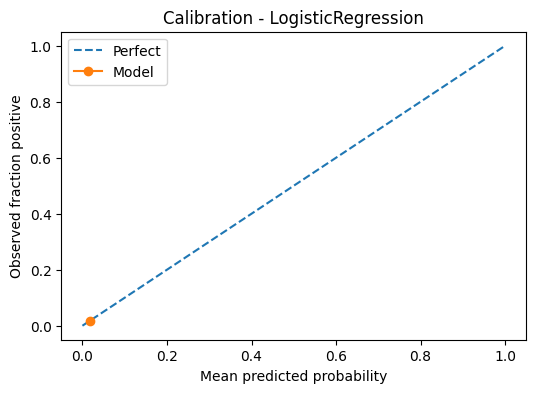

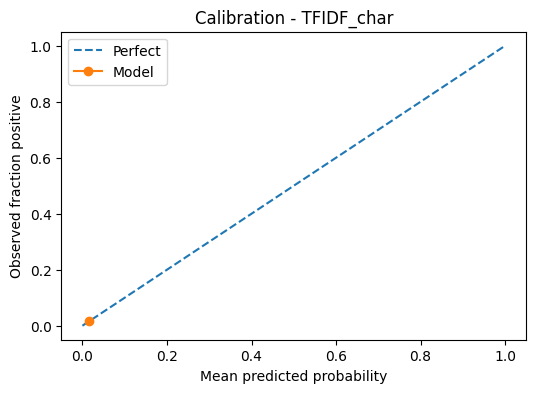

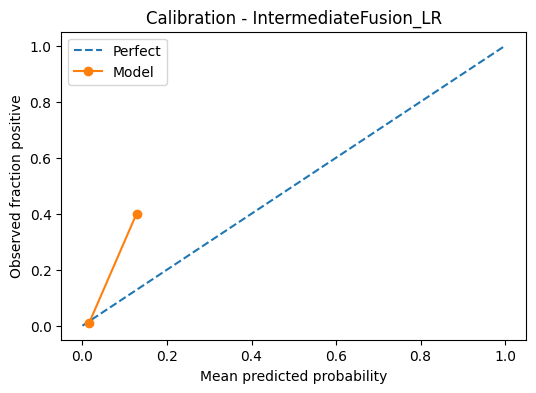

In [ ]:
# ============================================================
# Cell 24: Calibration comparison
# Adapted for diabetes cohort -> stroke prediction
# Compare the best model in each family using:
# 1) F2-optimized rows only
# 2) PR AUC as the main ranking metric
# ============================================================

# Best tabular model
best_tabular_overall = (
    tabular_results_df[tabular_results_df["operating_point"] == "F2_optimized"]
    .sort_values(["pr_auc", "recall"], ascending=[False, False])
    .iloc[0]
)

# Best text model
best_text_overall = (
    text_results_df[text_results_df["operating_point"] == "F2_optimized"]
    .sort_values(["pr_auc", "recall"], ascending=[False, False])
    .iloc[0]
)

# Best multimodal model
best_multi_overall = (
    multimodal_results_df[multimodal_results_df["operating_point"] == "F2_optimized"]
    .sort_values(["pr_auc", "recall"], ascending=[False, False])
    .iloc[0]
)

print("Best tabular:", best_tabular_overall["model_name"])
print("Best text:", best_text_overall["model_name"])
print("Best multimodal:", best_multi_overall["model_name"])

# Tabular calibration curve
plot_calibration_curve_custom(
    y_test,
    tabular_test_probs[best_tabular_overall["model_name"]],
    title=f"Calibration - {best_tabular_overall['model_name']}",
)

# Text calibration curve
plot_calibration_curve_custom(
    y_test,
    text_test_probs[best_text_overall["model_name"]],
    title=f"Calibration - {best_text_overall['model_name']}",
)

# Multimodal calibration curve
plot_calibration_curve_custom(
    y_test,
    multimodal_test_probs[best_multi_overall["model_name"]],
    title=f"Calibration - {best_multi_overall['model_name']}",
)

explaining colaboration results:What you’re seeing
Only 1–2 points instead of a smooth curve
Points clustered near very low probabilities (≈ 0–0.2)
Almost no spread across the x-axis
🎯 The main reason: very few positive cases

From your results:

Test set ≈ 703 patients
Positives ≈ 12 strokes

👉 That is extremely imbalanced

What calibration needs

Calibration curves split predictions into bins (e.g., 10 bins)

But in your case:

Most predictions are very small probabilities
Very few high-risk predictions exist
Some bins have 0 positive cases

👉 So the plot collapses into just a few visible points

🔍 Model-by-model explanation
1. Tabular (Logistic Regression)
Predicts very low probabilities for almost everyone
So everything falls into one tiny bin near 0

👉 That’s why you see:

one point near (0, ~0)
2. TFIDF_char (your best model)
Slightly better spread
Some patients get higher predicted risk

👉 So

Interpretation and explainability

Interpretation is different for different model families.

We will do three things:

    SHAP for the best tabular XGBoost model
    Top weighted tokens for the best sparse linear text model
    SHAP + modality aggregation for the hybrid fusion model

This gives you:

    feature-level interpretability for structured data,
    token-level interpretability for sparse text,
    modality-level explainability for the richest multimodal model.


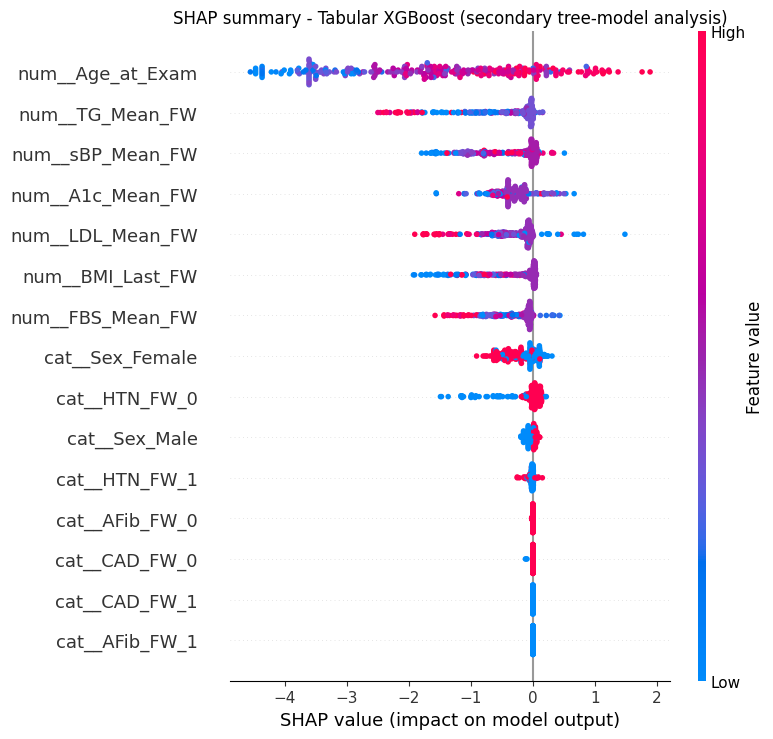

In [ ]:
# ============================================================
# Cell 25B: SHAP for tabular XGBoost (secondary analysis only)
# NOT the best tabular model in this project
# ============================================================

def coerce_binary_shap_values(shap_values):
    if isinstance(shap_values, list):
        if len(shap_values) == 2:
            return np.asarray(shap_values[1])
        return np.asarray(shap_values[0])

    arr = np.asarray(shap_values)

    if arr.ndim == 3:
        if arr.shape[-1] == 2:
            return arr[:, :, 1]
        if arr.shape[0] == 2:
            return arr[1]

    return arr

if "XGBoost" in tabular_models:
    tab_xgb_model = tabular_models["XGBoost"]

    shap_sample_size = min(300, len(tab_test_dense))
    shap_idx = np.random.RandomState(RANDOM_STATE).choice(
        len(tab_test_dense), shap_sample_size, replace=False
    )
    X_tab_shap = tab_test_dense[shap_idx]

    tab_explainer = shap.TreeExplainer(tab_xgb_model)
    tab_shap_values_raw = tab_explainer.shap_values(X_tab_shap)
    tab_shap_values = coerce_binary_shap_values(tab_shap_values_raw)

    plt.figure()
    shap.summary_plot(
        tab_shap_values,
        X_tab_shap,
        feature_names=tabular_feature_names,
        max_display=15,
        show=False,
    )
    plt.title("SHAP summary - Tabular XGBoost (secondary tree-model analysis)")
    plt.tight_layout()
    plt.show()
else:
    print("Tabular XGBoost model not available.")

Best tabular model: LogisticRegression


,feature,coefficient,abs_coefficient
14,cat__CAD_FW_1,-1.241875,1.241875
0,num__Age_at_Exam,1.025508,1.025508
13,cat__CAD_FW_0,0.845881,0.845881
11,cat__AFib_FW_0,-0.461980,0.461980
7,cat__Sex_Female,-0.391096,0.391096
5,num__FBS_Mean_FW,-0.310374,0.310374
9,cat__HTN_FW_0,-0.269571,0.269571
6,num__BMI_Last_FW,0.235413,0.235413
3,num__LDL_Mean_FW,-0.163925,0.163925
10,cat__HTN_FW_1,-0.126423,0.126423


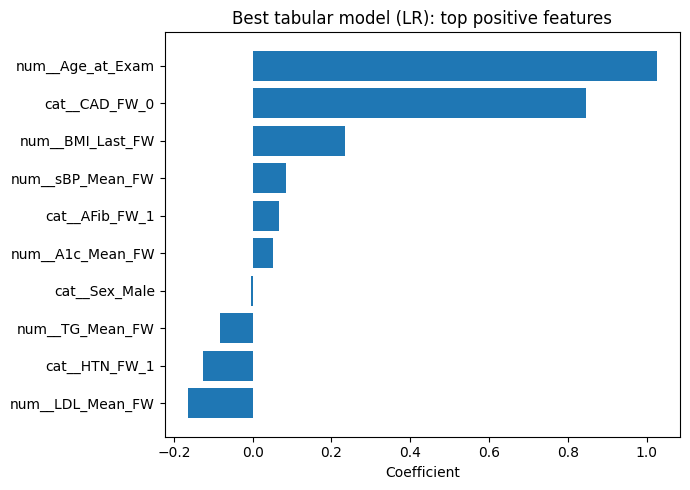

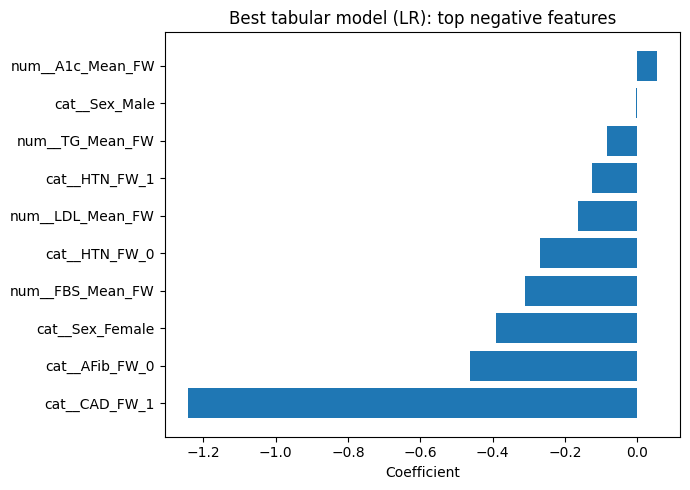

In [ ]:
# ============================================================
# Cell 25A: Tabular interpretation
# Adapted for diabetes cohort -> stroke prediction
#
# IMPORTANT:
# - Best tabular model = LogisticRegression
# - XGBoost is NOT the best tabular model in this project
# - We therefore do:
#   (1) coefficient-based interpretation for the best tabular model
#   (2) SHAP only for the XGBoost tree model as a secondary analysis
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# ------------------------------------------------------------
# Part 1: Best tabular model = LogisticRegression
# Coefficient-based interpretation
# ------------------------------------------------------------
best_tabular_row = (
    tabular_results_df[tabular_results_df["operating_point"] == "F2_optimized"]
    .sort_values(["pr_auc", "recall"], ascending=[False, False])
    .iloc[0]
)

print("Best tabular model:", best_tabular_row["model_name"])

if best_tabular_row["model_name"] == "LogisticRegression":
    best_tab_lr = tabular_models["LogisticRegression"]

    # Extract coefficients from the LR inside the pipeline
    lr_coef = best_tab_lr.named_steps["clf"].coef_[0]
    lr_feature_names = best_tab_lr.named_steps["preprocessor"].get_feature_names_out()

    coef_df = pd.DataFrame({
        "feature": lr_feature_names,
        "coefficient": lr_coef,
        "abs_coefficient": np.abs(lr_coef),
    }).sort_values("abs_coefficient", ascending=False)

    display(coef_df)

    top_pos = coef_df.sort_values("coefficient", ascending=False).head(10)
    top_neg = coef_df.sort_values("coefficient", ascending=True).head(10)

    plt.figure(figsize=(7, 5))
    plt.barh(top_pos["feature"][::-1], top_pos["coefficient"][::-1])
    plt.title("Best tabular model (LR): top positive features")
    plt.xlabel("Coefficient")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.barh(top_neg["feature"], top_neg["coefficient"])
    plt.title("Best tabular model (LR): top negative features")
    plt.xlabel("Coefficient")
    plt.tight_layout()
    plt.show()

else:
    print("Best tabular model is not LogisticRegression. Check tabular_results_df.")

In [ ]:
# ============================================================
# Cell 26: Interpretation for the best sparse linear text model
# Adapted for diabetes cohort -> stroke prediction
#
# IMPORTANT:
# Your best sparse model is TFIDF_char, so the features are
# character n-grams, not full words.
# ============================================================

best_sparse_clf = text_models[best_sparse_text_name]
best_sparse_vectorizer = text_vectorizers[best_sparse_text_name]

feature_names = np.array(best_sparse_vectorizer.get_feature_names_out())
coefs = best_sparse_clf.coef_.ravel()

top_pos_idx = np.argsort(coefs)[-20:][::-1]
top_neg_idx = np.argsort(coefs)[:20]

top_positive_features = pd.DataFrame({
    "feature": feature_names[top_pos_idx],
    "coefficient": coefs[top_pos_idx],
})

top_negative_features = pd.DataFrame({
    "feature": feature_names[top_neg_idx],
    "coefficient": coefs[top_neg_idx],
})

print(f"Best sparse text model: {best_sparse_text_name}")
print("\nTop positive-risk text features:")
display(top_positive_features)

print("\nTop negative-risk text features:")
display(top_negative_features)

Best sparse text model: TFIDF_char

Top positive-risk text features:


,feature,coefficient
0,v.a.,10.106720
1,c.v.,10.042183
2,c.v,10.042183
3,c.v.a,10.039539
4,v.a.,10.039539
5,.v.a,10.039539
6,v.a,10.039539
7,c.v.,10.039539
8,c.v,10.039539
9,.v.a.,10.039539



Top negative-risk text features:


,feature,coefficient
0,eral,-1.484307
1,ty|,-1.332480
2,sit,-1.326617
3,neral,-1.255562
4,est,-1.252772
5,eral,-1.244612
6,htn,-1.241966
7,ity|,-1.213508
8,esi,-1.202595
9,obe,-1.192581


In [ ]:
sample = "Patient had ischemic stroke and TIA after prior stroke."
print(delete_outcome_terms(sample))

for d in [train_df, val_df, test_df]:
    d["text_cleaned"] = d["concat(DiagnosisText_Orig)"].fillna("").astype(str).apply(delete_outcome_terms)

    print(train_df["concat(DiagnosisText_Orig)"].iloc[0])
print()
print(train_df["text_cleaned"].iloc[0])


Patient had and after prior .


In [ ]:
# ============================================================
# Top features for best text model (TFIDF_char)
# ============================================================

import numpy as np
import pandas as pd

best_sparse_clf = text_models["TFIDF_char"]
best_sparse_vectorizer = text_vectorizers["TFIDF_char"]

feature_names = np.array(best_sparse_vectorizer.get_feature_names_out())
coefs = best_sparse_clf.coef_.ravel()

# Top positive (stroke risk)
top_pos_idx = np.argsort(coefs)[-20:][::-1]

# Top negative (non-stroke)
top_neg_idx = np.argsort(coefs)[:20]

top_positive_tokens = pd.DataFrame({
    "token": feature_names[top_pos_idx],
    "coefficient": coefs[top_pos_idx],
})

top_negative_tokens = pd.DataFrame({
    "token": feature_names[top_neg_idx],
    "coefficient": coefs[top_neg_idx],
})

display(top_positive_tokens)
display(top_negative_tokens)

,token,coefficient
0,v.a.,10.106720
1,c.v.,10.042183
2,c.v,10.042183
3,c.v.a,10.039539
4,v.a.,10.039539
5,.v.a,10.039539
6,v.a,10.039539
7,c.v.,10.039539
8,c.v,10.039539
9,.v.a.,10.039539


,token,coefficient
0,eral,-1.484307
1,ty|,-1.332480
2,sit,-1.326617
3,neral,-1.255562
4,est,-1.252772
5,eral,-1.244612
6,htn,-1.241966
7,ity|,-1.213508
8,esi,-1.202595
9,obe,-1.192581


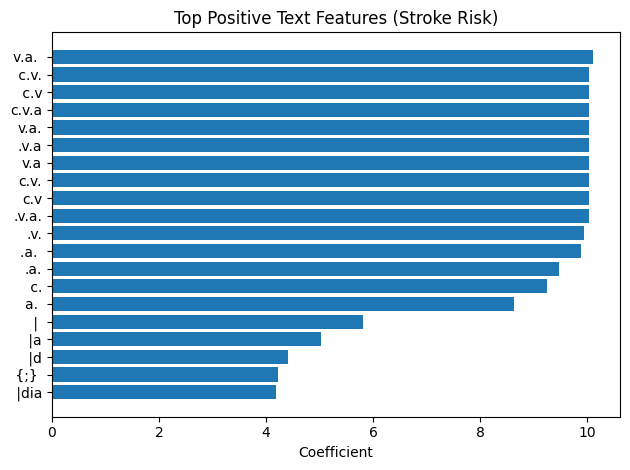

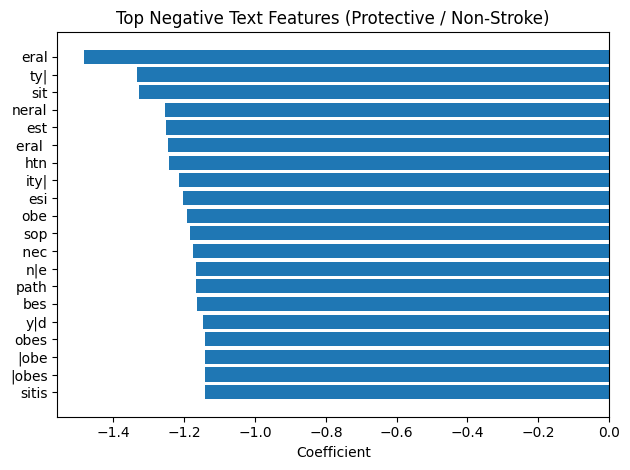

In [ ]:
# ============================================================
# Plot top text features
# ============================================================

import matplotlib.pyplot as plt

# Positive features
plt.figure()
plt.barh(top_positive_tokens["token"][::-1], top_positive_tokens["coefficient"][::-1])
plt.title("Top Positive Text Features (Stroke Risk)")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

# Negative features
plt.figure()
plt.barh(top_negative_tokens["token"][::-1], top_negative_tokens["coefficient"][::-1])
plt.title("Top Negative Text Features (Protective / Non-Stroke)")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()